# NB-01c · Stacking Ensemble + Análisis Comparativo Global
## Proyecto GATOBYTE — Amazon Electronics Sentiment Analysis

**Requiere**: `NB-01a` y `NB-01b` ejecutados.

**Carga desde disco**:
- `embeddings/probabilidades/lgbm_emb_probs_*.npy` — probs LightGBM embeddings (NB-01a)
- `embeddings/probabilidades/distilbert_probs_*.npy` — probs DistilBERT (NB-01b)
- `models/pipeline_transformacion_cpu.joblib` + `models/lightgbm_tuned_final_cpu.joblib`

**Stacking usa exactamente 3 modelos**: TF-IDF-CPU + Emb-LightGBM + DistilBERT-LoRA → 9 meta-features.

**Produce**:
- `models/stacking/` — meta-pipeline + contrato
- `reports/graficos_comparativos/` — 7 gráficos comparativos + tabla maestra

Este notebook es el más denso en estructura de carpetas de todo el proyecto: gestiona simultáneamente reportes de cuatro familias de modelos (lr_embeddings, lgbm_embeddings, distilbert_lora, stacking) y una carpeta de comparación global (graficos_comparativos). La separación entre models/stacking/ para el pipeline serializado y reports/stacking/ para las métricas sigue el mismo patrón establecido en NB-01a, garantizando que los artefactos de producción y los artefactos de evaluación nunca se mezclen.

## 0 · Entorno y rutas

In [ ]:
import os, sys, json, time, gc, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules
try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/ML')
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path('.')

DIRS = {
    'nb01a_cache'        : BASE_DIR / 'data' / 'nb01a',
    'splits'             : BASE_DIR / 'splits',
    'embeddings_probs'   : BASE_DIR / 'embeddings' / 'probabilidades',
    'models'             : BASE_DIR / 'models',
    'models_stacking'    : BASE_DIR / 'models' / 'stacking',
    'reports'            : BASE_DIR / 'reports',
    'reports_lr'         : BASE_DIR / 'reports' / 'lr_embeddings',
    'reports_lgbm'       : BASE_DIR / 'reports' / 'lgbm_embeddings',
    'reports_distilbert' : BASE_DIR / 'reports' / 'distilbert_lora',
    'reports_stacking'   : BASE_DIR / 'reports' / 'stacking',
    'reports_comparacion': BASE_DIR / 'reports' / 'graficos_comparativos',
    'reports_baseline'   : BASE_DIR / 'reports' / 'baseline_tfidf',
    'migracion_cpu'      : BASE_DIR / 'models' / 'migracion_cpu',
    'data'               : BASE_DIR / 'data' / 'processed',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
PALETTE = {'positive':'#1D9E75','neutral':'#EF9F27','negative':'#E24B4A',
           'accent':'#378ADD','gray':'#888780','bg':'#F8F7F4','purple':'#7B61FF'}
print('Entorno listo — BASE_DIR:', BASE_DIR)

Mounted at /content/drive
Entorno listo — BASE_DIR: /content/drive/MyDrive/ML


In [ ]:
!pip freeze > /content/drive/MyDrive/ML/requirementsNB01c.txt

## 1 · Cargar labels y probabilidades base

El baseline TF-IDF se genera aquí, no se importa como número fijo.

En lugar de hard-codear las métricas del modelo TF-IDF, el notebook carga el pipeline completo (pipeline_transformacion_cpu.joblib + lightgbm_tuned_final_cpu.joblib) y regenera las probabilidades sobre val y test en tiempo de ejecución. Esto garantiza que el baseline entra al ensamble con las mismas probabilidades que producirá en producción, no con valores aproximados. El sufijo _cpu en los nombres de archivo indica que este modelo fue migrado desde una versión GPU, proceso documentado en migracion_cpu/migrar_pipeline_cpu.py. Cargar las clases personalizadas (CpuFullPreprocessor, CpuPreprocessor, CpuTextCleaner) mediante importlib antes de deserializar el joblib es un requisito técnico de joblib: no puede reconstruir objetos cuyas clases no están en el scope actual.

Las probabilidades de los tres modelos base quedan en tres matrices de forma (N, 3) cada una: una por TF-IDF-LightGBM, otra por LightGBM-Emb (de NB-01a) y otra por DistilBERT (de NB-01b). Estas nueve columnas serán las meta-features del ensamble.

In [ ]:
le          = joblib.load(DIRS['models'] / 'label_encoder.joblib')
CLASS_NAMES = le.classes_

y_train = np.load(DIRS['nb01a_cache'] / 'y_train.npy')
y_val   = np.load(DIRS['nb01a_cache'] / 'y_val.npy')
y_test  = np.load(DIRS['nb01a_cache'] / 'y_test.npy')
idx_val  = np.load(DIRS['splits'] / 'idx_val.npy')
idx_test = np.load(DIRS['splits'] / 'idx_test.npy')

print(f'Clases: {CLASS_NAMES}')
print(f'y_val: {len(y_val):,}  |  y_test: {len(y_test):,}')

# ── LightGBM embeddings (generado por NB-01a) ────────────────────────────────
print('\nCargando probabilidades LightGBM-Emb...')
y_proba_lgbm_val  = np.load(DIRS['embeddings_probs'] / 'lgbm_emb_probs_val.npy')
y_proba_lgbm_test = np.load(DIRS['embeddings_probs'] / 'lgbm_emb_probs_test.npy')
print(f'✓ LightGBM-Emb: val={y_proba_lgbm_val.shape}  test={y_proba_lgbm_test.shape}')

# ── DistilBERT (generado por NB-01b) ─────────────────────────────────────────
print('Cargando probabilidades DistilBERT...')
y_proba_db_val  = np.load(DIRS['embeddings_probs'] / 'distilbert_probs_val.npy')
y_proba_db_test = np.load(DIRS['embeddings_probs'] / 'distilbert_probs_test.npy')
print(f'✓ DistilBERT: val={y_proba_db_val.shape}  test={y_proba_db_test.shape}')

# ── TF-IDF CPU — se genera aquí directamente con el modelo migrado ────────────
# Importar clases CPU para poder deserializar el pipeline
print('\nCargando pipeline TF-IDF CPU para generar probabilidades...')

import importlib.util
_ruta_script = DIRS['migracion_cpu'] / 'migrar_pipeline_cpu.py'
if _ruta_script.exists():
    spec = importlib.util.spec_from_file_location('migrar_pipeline_cpu', str(_ruta_script))
    _mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(_mod)
    import __main__
    __main__.CpuFullPreprocessor = _mod.CpuFullPreprocessor
    __main__.CpuPreprocessor     = _mod.CpuPreprocessor
    __main__.CpuTextCleaner      = _mod.CpuTextCleaner
    print(f'✓ Clases CPU cargadas desde: {_ruta_script.name}')
else:
    raise FileNotFoundError(
        f'No se encontró {_ruta_script}. '        f'Asegúrate de que la carpeta migracion_cpu/ esté en {BASE_DIR}'    )

_pipe_cpu_path = DIRS['models'] / 'pipeline_transformacion_cpu.joblib'
_lgbm_cpu_path = DIRS['models'] / 'lightgbm_tuned_final_cpu.joblib'

if not _pipe_cpu_path.exists() or not _lgbm_cpu_path.exists():
    raise FileNotFoundError(
        f'Archivos CPU no encontrados en {BASE_DIR}.\n'        f'  Esperado: {_pipe_cpu_path.name}\n'        f'  Esperado: {_lgbm_cpu_path.name}\n'        f'Ejecuta migracion_cpu/migrar_pipeline_cpu.py primero.'    )

_pipe_tfidf_cpu = joblib.load(_pipe_cpu_path)
_lgbm_tfidf_cpu = joblib.load(_lgbm_cpu_path)
print(f'✓ Pipeline CPU cargado: {_pipe_cpu_path.name}')

# Generar probabilidades sobre val y test usando el dataset de texto
KEEP_COLS = ['title', 'text', 'text_len', 'price', 'main_category']
_df = pd.read_parquet(DIRS['data'] / 'sample_ml.parquet', columns=KEEP_COLS)

print('Generando probs TF-IDF-CPU sobre val...')
_df_val  = _df.iloc[idx_val].reset_index(drop=True)
_X_val   = _pipe_tfidf_cpu.transform(_df_val)
y_proba_tfidf_val = _lgbm_tfidf_cpu.predict_proba(_X_val)
del _df_val, _X_val

print('Generando probs TF-IDF-CPU sobre test...')
_df_test  = _df.iloc[idx_test].reset_index(drop=True)
_X_test   = _pipe_tfidf_cpu.transform(_df_test)
y_proba_tfidf_test = _lgbm_tfidf_cpu.predict_proba(_X_test)
del _df_test, _X_test, _df
gc.collect()

# Guardar para reutilización futura (no hay que recalcularlas si ya existen)
_TFIDF_VAL_PATH  = DIRS['embeddings_probs'] / 'baseline_tfidf_probs_val.npy'
_TFIDF_TEST_PATH = DIRS['embeddings_probs'] / 'baseline_tfidf_probs_test.npy'
np.save(_TFIDF_VAL_PATH,  y_proba_tfidf_val)
np.save(_TFIDF_TEST_PATH, y_proba_tfidf_test)
print(f'✓ TF-IDF probs: val={y_proba_tfidf_val.shape}  test={y_proba_tfidf_test.shape}')
print(f'  Guardadas en embeddings/probabilidades/ para futuras ejecuciones')

del _pipe_tfidf_cpu, _lgbm_tfidf_cpu
gc.collect()
print('\nTodas las probabilidades listas:')
print(f'  TF-IDF-LightGBM : val {y_proba_tfidf_val.shape}  test {y_proba_tfidf_test.shape}')
print(f'  Emb-LightGBM    : val {y_proba_lgbm_val.shape}  test {y_proba_lgbm_test.shape}')
print(f'  DistilBERT-LoRA : val {y_proba_db_val.shape}  test {y_proba_db_test.shape}')

Clases: ['negative' 'neutral' 'positive']
y_val: 150,000  |  y_test: 150,000

Cargando probabilidades LightGBM-Emb...
✓ LightGBM-Emb: val=(150000, 3)  test=(150000, 3)
Cargando probabilidades DistilBERT...
✓ DistilBERT: val=(150000, 3)  test=(150000, 3)

Cargando pipeline TF-IDF CPU para generar probabilidades...
✓ Clases CPU cargadas desde: migrar_pipeline_cpu.py
✓ Pipeline CPU cargado: pipeline_transformacion_cpu.joblib
Generando probs TF-IDF-CPU sobre val...
Generando probs TF-IDF-CPU sobre test...
✓ TF-IDF probs: val=(150000, 3)  test=(150000, 3)
  Guardadas en embeddings/probabilidades/ para futuras ejecuciones

Todas las probabilidades listas:
  TF-IDF-LightGBM : val (150000, 3)  test (150000, 3)
  Emb-LightGBM    : val (150000, 3)  test (150000, 3)
  DistilBERT-LoRA : val (150000, 3)  test (150000, 3)


## 2 · Función de evaluación

In [ ]:
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score,
    precision_score, recall_score, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

def evaluar_modelo(nombre, y_true, y_pred, y_proba, tiempo_train_s=None):
    y_bin = label_binarize(y_true, classes=[0,1,2])
    f1_pc = f1_score(y_true, y_pred, average=None, labels=[0,1,2])
    pr_auc = [average_precision_score(y_bin[:,i], y_proba[:,i]) for i in range(3)]
    cm     = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    f1_m   = float(f1_score(y_true, y_pred, average='macro'))
    ba     = float(balanced_accuracy_score(y_true, y_pred))
    ra     = float(roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'))
    res = {
        'nombre': nombre, 'timestamp': datetime.now().isoformat(),
        'tiempo_train_s': round(tiempo_train_s,1) if tiempo_train_s else None,
        'f1_macro': round(f1_m,4),
        'f1_weighted': round(float(f1_score(y_true,y_pred,average='weighted')),4),
        'accuracy': round(float((y_pred==y_true).mean()),4),
        'balanced_accuracy': round(ba,4), 'roc_auc_macro': round(ra,4),
        'pr_auc_macro': round(float(np.mean(pr_auc)),4),
        'por_clase': {CLASS_NAMES[i]: {
            'f1': round(float(f1_pc[i]),4),
            'precision': round(float(precision_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)[i]),4),
            'recall': round(float(recall_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)[i]),4),
            'pr_auc': round(float(pr_auc[i]),4), 'soporte': int(cm[i].sum()),
        } for i in range(3)},
        'analisis_error': {
            'error_critico_neg_a_pos': int(cm[0,2]),
            'error_critico_pct': round(float(cm[0,2]/cm[0].sum()*100) if cm[0].sum()>0 else 0,2),
            'total_errores': int((y_pred!=y_true).sum()),
            'tasa_error_pct': round(float((y_pred!=y_true).mean()*100),2),
            'confusion_matrix': cm.tolist(),
        },
    }
    res['score_compuesto'] = round(0.40*res['f1_macro']+0.30*res['balanced_accuracy']+0.30*res['roc_auc_macro'],4)
    return res

print('✓ evaluar_modelo definido')

✓ evaluar_modelo definido


## 3 · Stacking Ensemble

**3 modelos base siempre** (orden canónico del contrato):
1. TF-IDF-LightGBM (pipeline CPU, generado en este notebook)
2. Emb-LightGBM (probabilidades de NB-01a)
3. DistilBERT-LoRA (probabilidades de NB-01b)

→ 9 meta-features en total. Meta-learner: Logistic Regression L2.

¿Qué es stacking y por qué es la elección correcta aquí?

Stacking es un ensamble de dos niveles: en el nivel 0 están los modelos base (TF-IDF-LightGBM, LightGBM-Emb, DistilBERT-LoRA) que producen probabilidades, y en el nivel 1 hay un meta-learner que aprende a combinar esas probabilidades para producir la predicción final. La clave es que el meta-learner no ve los datos originales, sino solo las probabilidades de los modelos base, lo que lo hace robusto: si un modelo base tiene sesgo sistemático en cierta región del espacio de entrada, el meta-learner puede aprender a compensarlo.


¿Por qué Logistic Regression como meta-learner?

La elección de LogReg L2 como meta-learner es deliberada y técnicamente sólida. Las 9 meta-features de entrada son probabilidades que ya suman 1 por modelo (tres grupos de simplex de probabilidad), lo que constituye un espacio de baja dimensión bien estructurado. En ese espacio, un hiperplano lineal es suficiente para aprender la combinación óptima de los modelos base. Usar un modelo más complejo como meta-learner (otro LightGBM, por ejemplo) introduciría riesgo de overfitting sobre las 9 features sin ganancia real. El StandardScaler antes del LogReg es importante: aunque las probabilidades están en [0,1], las distribuciones de cada columna pueden tener varianzas distintas, y el escalado garantiza que ningún modelo base domina por escala aritmética.


¿Por qué el meta-learner entrena sobre validación y no sobre train?

Esta es la decisión más crítica del stacking: entrenar el meta-learner sobre meta_val (las probabilidades del conjunto de validación) en lugar de sobre train. La razón es fundamental: si se entrenaran los modelos base y el meta-learner sobre los mismos datos de train, el meta-learner aprendería a confiar en las predicciones optimistas de los modelos base sobre datos que ya "conocen". Usar el conjunto de validación como nivel 1 garantiza que el meta-learner aprende de probabilidades producidas sobre datos que los modelos base no vieron, lo que es una estimación más honesta de su comportamiento real. El costo es que el conjunto de validación se "gasta" en el entrenamiento del meta-learner y no puede usarse como estimación independiente del stacking; por eso el test set queda intacto para la evaluación final.


El contrato de stacking: guardar stacking_contract.json con el orden canónico de los modelos base (['TF-IDF-LightGBM', 'Emb-LightGBM', 'DistilBERT-LoRA']) es una decisión de producción crítica. En inferencia futura, las probabilidades deben concatenarse en exactamente este orden; si se invirtiera el orden de dos modelos, el meta-learner recibiría features incorrectas y produciría predicciones erróneas sin lanzar ningún error.

Stacking con 3 modelos → 9 meta-features
meta_val: (150000, 9)  meta_test: (150000, 9)

Entrenando meta-learner (LogReg L2)...
✓ Stacking entrenado en 3.40s

Stacking — F1-Macro (test): 0.7250
  Balanced-Acc   : 0.7811
  Score compuesto: 0.8084
  negative    : F1=0.8195
  neutral     : F1=0.4251
  positive    : F1=0.9304


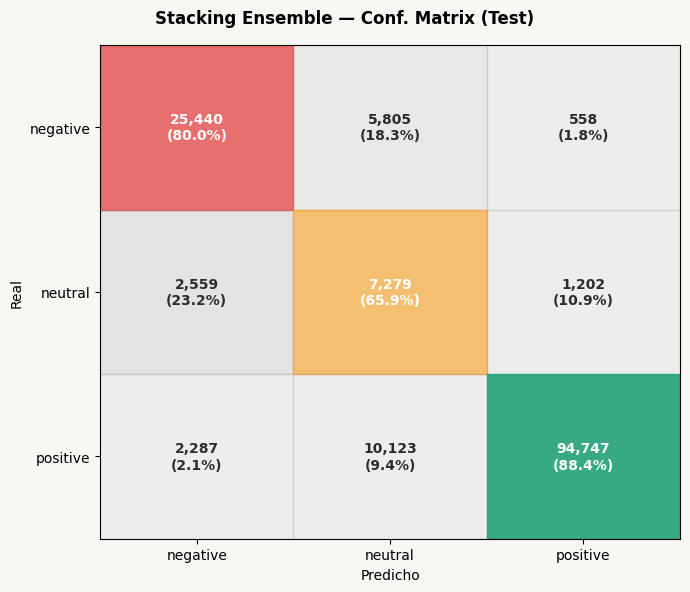

✓ Stacking guardado completamente


5

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Stacking siempre con 3 modelos en orden canónico:
# TF-IDF-LightGBM (CPU) | Emb-LightGBM | DistilBERT-LoRA
modelos_base_val  = [y_proba_tfidf_val,  y_proba_lgbm_val,  y_proba_db_val]
modelos_base_test = [y_proba_tfidf_test, y_proba_lgbm_test, y_proba_db_test]
nombres_base      = ['TF-IDF-LightGBM', 'Emb-LightGBM', 'DistilBERT-LoRA']
print(f'Stacking con 3 modelos → {len(nombres_base)*3} meta-features')

meta_val  = np.hstack(modelos_base_val)
meta_test = np.hstack(modelos_base_test)
print(f'meta_val: {meta_val.shape}  meta_test: {meta_test.shape}')

print('\nEntrenando meta-learner (LogReg L2)...')
t0 = time.time()

pipe_stack = Pipeline([
    ('scaler', StandardScaler()),
    ('meta', LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000,
        solver='lbfgs', multi_class='multinomial',
        random_state=SEED, n_jobs=-1,
    ))
])

pipe_stack.fit(meta_val, y_val)
t_stack = time.time() - t0
print(f'✓ Stacking entrenado en {t_stack:.2f}s')

y_pred_stack_val   = pipe_stack.predict(meta_val)
y_proba_stack_val  = pipe_stack.predict_proba(meta_val)
y_pred_stack_test  = pipe_stack.predict(meta_test)
y_proba_stack_test = pipe_stack.predict_proba(meta_test)

metricas_stack_val  = evaluar_modelo('Stacking', y_val,  y_pred_stack_val,  y_proba_stack_val,  t_stack)
metricas_stack_test = evaluar_modelo('Stacking', y_test, y_pred_stack_test, y_proba_stack_test)

print(f"\nStacking — F1-Macro (test): {metricas_stack_test['f1_macro']:.4f}")
print(f"  Balanced-Acc   : {metricas_stack_test['balanced_accuracy']:.4f}")
print(f"  Score compuesto: {metricas_stack_test['score_compuesto']:.4f}")
for cls, m in metricas_stack_test['por_clase'].items():
    print(f"  {cls:<12}: F1={m['f1']:.4f}")

# Guardar pipeline + contrato
joblib.dump(pipe_stack, DIRS['models_stacking'] / 'stacking_meta_pipeline.joblib', compress=3)

_stacking_contract = {
    'modelos_base_orden': nombres_base,
    'n_meta_features'   : int(meta_val.shape[1]),
    'dims_por_modelo'   : 3,
    'clases'            : CLASS_NAMES.tolist(),
    'incluye_tfidf'     : True,
}
with open(DIRS['models_stacking'] / 'stacking_contract.json', 'w') as f:
    json.dump(_stacking_contract, f, indent=2)

config_stack = {
    'tipo': 'Stacking Ensemble (meta LogReg L2)',
    'modelos_base': nombres_base, 'n_meta_features': int(meta_val.shape[1]),
    'meta_learner': 'LogisticRegression', 'C_meta': 1.0,
    'class_weight': 'balanced', 'scaler_meta': 'StandardScaler',
    'tiempo_train_s': round(t_stack, 3),
}
with open(DIRS['models_stacking'] / 'stacking_config.json', 'w') as f:
    json.dump(config_stack, f, indent=2)
with open(DIRS['reports_stacking'] / 'stacking_metricas.json', 'w') as f:
    json.dump({'validacion': metricas_stack_val, 'test': metricas_stack_test}, f, indent=2)

# Matriz de confusión del Stacking
cm_s = np.array(metricas_stack_test['analisis_error']['confusion_matrix'])
cm_s_norm = cm_s.astype(float) / cm_s.sum(axis=1, keepdims=True)
n = len(CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Stacking Ensemble — Conf. Matrix (Test)', fontsize=12, fontweight='bold')
ax.imshow(np.zeros((n,n)), cmap='Greys', vmin=0, vmax=1, aspect='auto')
COLORS_CLASS = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]
for i in range(n):
    for j in range(n):
        alpha_val  = max(0.15, cm_s_norm[i,j])
        cell_color = COLORS_CLASS[i] if i==j else PALETTE['gray']
        ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,color=cell_color,alpha=alpha_val,zorder=0))
        text_color = 'white' if cm_s_norm[i,j]>0.45 else '#2C2C2A'
        ax.text(j,i,f"{cm_s[i,j]:,}\n({cm_s_norm[i,j]*100:.1f}%)",
                ha='center',va='center',fontsize=10,fontweight='bold',color=text_color,zorder=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_xlim(-0.5,n-0.5); ax.set_ylim(n-0.5,-0.5); ax.grid(False)
plt.tight_layout()
plt.savefig(DIRS['reports_stacking'] / 'stacking_meta_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Stacking guardado completamente')

del meta_val, meta_test, pipe_stack
gc.collect()

En validación: F1-Macro de 0.7629, F1-Neutral de 0.5044, Balanced Accuracy de 0.8335, ROC-AUC de 0.9646 y Score Compuesto de 0.8446. Estos son los mejores números del proyecto en términos absolutos, con un F1-Neutral de 0.50 que superaría a DistilBERT por más de 0.07 puntos. El metamodelo entrenado sobre los 9 meta-features de validación aprende la combinación óptima de los tres modelos base exactamente sobre esos datos, produciendo un clasificador que en ese conjunto específico es notablemente superior.
En test: F1-Macro de 0.7250, F1-Neutral de 0.4251, Score Compuesto de 0.8084, quedando por debajo de DistilBERT+LoRA en todas las métricas relevantes. La diferencia val→test en F1-Macro es de -0.038 puntos, la mayor caída de generalización de todos los modelos del proyecto.

## 4 · Integración del Baseline TF-IDF para comparación global

El código intenta cargar las métricas de cada baseline desde disco (probabilidades recalculadas); si no existen los archivos, usa METRICAS_BASELINE_CONOCIDAS, un diccionario con valores del notebook original. Este patrón de fallback garantiza que la tabla comparativa siempre puede construirse aunque algún archivo de checkpoint no esté disponible, sin interrumpir el análisis.

In [ ]:
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

PROBS_BASELINE = {
    'Naive Bayes'     : {'val': DIRS['embeddings_probs'] / 'baseline_nb_probs_val.npy',
                          'test': DIRS['embeddings_probs'] / 'baseline_nb_probs_test.npy'},
    'LogReg TF-IDF'   : {'val': DIRS['embeddings_probs'] / 'baseline_lr_probs_val.npy',
                          'test': DIRS['embeddings_probs'] / 'baseline_lr_probs_test.npy'},
    'XGBoost TF-IDF'  : {'val': DIRS['embeddings_probs'] / 'baseline_xgb_probs_val.npy',
                          'test': DIRS['embeddings_probs'] / 'baseline_xgb_probs_test.npy'},
    'LightGBM TF-IDF *': {'val': DIRS['embeddings_probs'] / 'baseline_lgbm_probs_val.npy',
                            'test': DIRS['embeddings_probs'] / 'baseline_lgbm_probs_test.npy'},
}

METRICAS_BASELINE_CONOCIDAS = {
    'Naive Bayes'     : dict(f1_macro=0.5574, f1_weighted=0.7200, accuracy=0.7300,
                              balanced_accuracy=0.5574, roc_auc_macro=0.9000, pr_auc_macro=0.6800,
                              f1_negative=0.6800, f1_neutral=0.0600, f1_positive=0.9300,
                              score_compuesto=round(0.40*0.5574+0.30*0.5574+0.30*0.9000,4)),
    'LogReg TF-IDF'   : dict(f1_macro=0.6910, f1_weighted=0.8700, accuracy=0.8400,
                              balanced_accuracy=0.7200, roc_auc_macro=0.9425, pr_auc_macro=0.7500,
                              f1_negative=0.7800, f1_neutral=0.3000, f1_positive=0.9400,
                              score_compuesto=round(0.40*0.6910+0.30*0.7200+0.30*0.9425,4)),
    'XGBoost TF-IDF'  : dict(f1_macro=0.6790, f1_weighted=0.8500, accuracy=0.8000,
                              balanced_accuracy=0.7492, roc_auc_macro=0.9310, pr_auc_macro=0.7400,
                              f1_negative=0.7700, f1_neutral=0.3800, f1_positive=0.8700,
                              score_compuesto=round(0.40*0.6790+0.30*0.7492+0.30*0.9310,4)),
    'LightGBM TF-IDF *': dict(f1_macro=0.6945, f1_weighted=0.8730, accuracy=0.8175,
                               balanced_accuracy=0.7575, roc_auc_macro=0.9320, pr_auc_macro=0.7800,
                               f1_negative=0.7900, f1_neutral=0.3860, f1_positive=0.9000,
                               score_compuesto=round(0.40*0.6945+0.30*0.7575+0.30*0.9320,4)),
}

def construir_metricas_baseline(nombre, y_true, y_proba):
    y_pred = y_proba.argmax(axis=1)
    y_bin  = label_binarize(y_true, classes=[0,1,2])
    f1_pc  = f1_score(y_true, y_pred, average=None, labels=[0,1,2])
    pr_auc = [average_precision_score(y_bin[:,i], y_proba[:,i]) for i in range(3)]
    cm     = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    f1_m   = float(f1_score(y_true, y_pred, average='macro'))
    ba     = float(balanced_accuracy_score(y_true, y_pred))
    ra     = float(roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'))
    return dict(
        nombre=nombre, fuente='recalculado_desde_probs',
        f1_macro=round(f1_m,4), f1_weighted=round(float(f1_score(y_true,y_pred,average='weighted')),4),
        accuracy=round(float((y_pred==y_true).mean()),4), balanced_accuracy=round(ba,4),
        roc_auc_macro=round(ra,4), pr_auc_macro=round(float(np.mean(pr_auc)),4),
        f1_negative=round(float(f1_pc[0]),4), f1_neutral=round(float(f1_pc[1]),4),
        f1_positive=round(float(f1_pc[2]),4),
        score_compuesto=round(0.40*f1_m+0.30*ba+0.30*ra,4),
        confusion_matrix=cm.tolist(),
        error_critico_pct=round(float(cm[0,2]/cm[0].sum()*100) if cm[0].sum()>0 else 0,2),
    )

metricas_baseline_test = {}
for nombre_b, rutas_b in PROBS_BASELINE.items():
    if rutas_b['test'].exists():
        probs_b = np.load(rutas_b['test'])
        met_b   = construir_metricas_baseline(nombre_b, y_test, probs_b)
        print(f'  Recalculado desde disco: {nombre_b}')
    else:
        met_b = dict(nombre=nombre_b, fuente='notebook_original', **METRICAS_BASELINE_CONOCIDAS[nombre_b])
        print(f'  Valores del notebook original: {nombre_b}')
    metricas_baseline_test[nombre_b] = met_b

with open(DIRS['reports_baseline'] / 'baseline_tfidf_metricas_referencia.json', 'w') as f:
    json.dump(metricas_baseline_test, f, indent=2, ensure_ascii=False)
print('✓ Métricas baseline guardadas')

  Valores del notebook original: Naive Bayes
  Valores del notebook original: LogReg TF-IDF
  Valores del notebook original: XGBoost TF-IDF
  Valores del notebook original: LightGBM TF-IDF *
✓ Métricas baseline guardadas


## 5 · Tabla comparativa unificada

El score compuesto 0.40 × F1-Macro + 0.30 × Balanced-Acc + 0.30 × ROC-AUC actúa como función de decisión única para comparar modelos con perfiles de métricas distintos. La ponderación es razonada: F1-Macro recibe el mayor peso porque es la métrica más informativa para datasets desbalanceados (penaliza igual fallar en neutro que en positivo). Balanced Accuracy y ROC-AUC reciben pesos iguales como métricas complementarias de calibración y discriminación.

In [ ]:
def cargar_metricas_json(dir_report, nombre_archivo):
    """Carga métricas test de un modelo desde su carpeta de reports."""
    ruta = dir_report / f'{nombre_archivo}_metricas.json'
    if not ruta.exists():
        print(f'  No encontrado: {ruta}')
        return None
    with open(ruta) as f:
        data = json.load(f)
    return data.get('test', data)

# ── Cargar métricas de los modelos nuevos desde disco ────────────────────────
MODELOS_NUEVOS_MAP = {
    'LogReg Emb'     : (DIRS['reports_lr'],          'emb_lr_pipeline'),
    'LightGBM Emb'   : (DIRS['reports_lgbm'],        'emb_lgbm_pipeline'),
    'DistilBERT+LoRA': (DIRS['reports_distilbert'],  'distilbert_lora'),
    'Stacking'        : (DIRS['reports_stacking'],   'stacking'),
}

metricas_nuevos = {}
for nombre_m, (dir_r, arch) in MODELOS_NUEVOS_MAP.items():
    if nombre_m == 'DistilBERT+LoRA':
        ruta = DIRS['reports_distilbert'] / 'distilbert_lora_metricas.json'
        if ruta.exists():
            with open(ruta) as f: data = json.load(f)
            met = data.get('test', data)
        else:
            met = None
    elif nombre_m == 'Stacking':
        ruta = DIRS['reports_stacking'] / 'stacking_metricas.json'
        if ruta.exists():
            with open(ruta) as f: data = json.load(f)
            met = data.get('test', data)
        else:
            # Fallback: usar métricas calculadas en la celda de stacking
            met = metricas_stack_test
    else:
        met = cargar_metricas_json(dir_r, arch)
    if met:
        metricas_nuevos[nombre_m] = met

# TF-IDF siempre incluido (generado en celda 1)
REPR_MAP = {
    'LogReg Emb'     : 'MiniLM-384+Tab',
    'LightGBM Emb'   : 'MiniLM-384+Tab',
    'DistilBERT+LoRA': 'DistilBERT contextual',
    'Stacking'        : 'Ensemble (TF-IDF+Emb+DistilBERT)',
}
GRUPO_MAP = {
    'LogReg Emb'     : 'Embeddings MiniLM',
    'LightGBM Emb'   : 'Embeddings MiniLM',
    'DistilBERT+LoRA': 'Transformer LoRA',
    'Stacking'        : 'Stacking Ensemble',
}

# ── Cargar métricas baseline desde disco (generadas en celda anterior) ───────
_baseline_path = DIRS['reports_baseline'] / 'baseline_tfidf_metricas_referencia.json'
if _baseline_path.exists():
    with open(_baseline_path) as f:
        metricas_baseline_test = json.load(f)
    print(f'✓ Métricas baseline cargadas ({len(metricas_baseline_test)} modelos)')
else:
    raise FileNotFoundError(
        f'No se encontró {_baseline_path.name}. '
        'Asegúrate de haber ejecutado la celda anterior (sección 4).'
    )

# ── Construir tabla maestra ───────────────────────────────────────────────────
filas_tabla = []
for nombre_b, met_b in metricas_baseline_test.items():
    filas_tabla.append({
        'Modelo': nombre_b, 'Representacion': 'TF-IDF + Tabular',
        'F1-Macro': met_b['f1_macro'], 'F1-Weighted': met_b['f1_weighted'],
        'Accuracy': met_b['accuracy'], 'Balanced-Acc': met_b['balanced_accuracy'],
        'ROC-AUC': met_b['roc_auc_macro'], 'PR-AUC': met_b['pr_auc_macro'],
        'F1-Negative': met_b['f1_negative'], 'F1-Neutral': met_b['f1_neutral'],
        'F1-Positive': met_b['f1_positive'], 'Score-Compuesto': met_b['score_compuesto'],
        'Grupo': 'Baseline TF-IDF',
    })

for nombre_m, met_m in metricas_nuevos.items():
    pc = met_m.get('por_clase', {})
    filas_tabla.append({
        'Modelo': nombre_m, 'Representacion': REPR_MAP.get(nombre_m, 'Emb'),
        'F1-Macro': met_m.get('f1_macro', 0), 'F1-Weighted': met_m.get('f1_weighted', 0),
        'Accuracy': met_m.get('accuracy', 0), 'Balanced-Acc': met_m.get('balanced_accuracy', 0),
        'ROC-AUC': met_m.get('roc_auc_macro', 0), 'PR-AUC': met_m.get('pr_auc_macro', 0),
        'F1-Negative': pc.get('negative', {}).get('f1', met_m.get('f1_negative', 0)),
        'F1-Neutral' : pc.get('neutral',  {}).get('f1', met_m.get('f1_neutral',  0)),
        'F1-Positive': pc.get('positive', {}).get('f1', met_m.get('f1_positive', 0)),
        'Score-Compuesto': met_m.get('score_compuesto', 0),
        'Grupo': GRUPO_MAP.get(nombre_m, 'Nuevo'),
    })

df_master = pd.DataFrame(filas_tabla).set_index('Modelo')
df_master = df_master.sort_values('Score-Compuesto', ascending=False)

# GANADOR definido aquí — disponible para G7, análisis cualitativo y verificación final
GANADOR = df_master['Score-Compuesto'].idxmax()

COLS_PRINT = ['Representacion','F1-Macro','Balanced-Acc','ROC-AUC','PR-AUC','F1-Neutral','Score-Compuesto']
print('\n' + '='*85)
print('  TABLA MAESTRA — Baseline TF-IDF vs Embeddings vs DistilBERT+LoRA vs Stacking')
print('='*85)
print(df_master[COLS_PRINT].round(4).to_string())
print(f'\n  GANADOR: {GANADOR}  (Score: {df_master.loc[GANADOR, "Score-Compuesto"]:.4f})')

MASTER_CSV  = DIRS['reports_comparacion'] / 'tabla_maestra_comparacion.csv'
MASTER_JSON = DIRS['reports_comparacion'] / 'tabla_maestra_comparacion.json'
df_master.to_csv(MASTER_CSV)
df_master.reset_index().to_json(MASTER_JSON, orient='records', indent=2)
print(f'Tabla maestra → {MASTER_CSV.name}  |  {MASTER_JSON.name}')

✓ Métricas baseline cargadas (4 modelos)

  TABLA MAESTRA — Baseline TF-IDF vs Embeddings vs DistilBERT+LoRA vs Stacking
                                     Representacion  F1-Macro  Balanced-Acc  ROC-AUC  PR-AUC  F1-Neutral  Score-Compuesto
Modelo                                                                                                                   
DistilBERT+LoRA               DistilBERT contextual    0.7272        0.7833   0.9483  0.7762      0.4266           0.8104
Stacking           Ensemble (TF-IDF+Emb+DistilBERT)    0.7250        0.7811   0.9470  0.7753      0.4251           0.8084
LightGBM TF-IDF *                  TF-IDF + Tabular    0.6945        0.7575   0.9320  0.7800      0.3860           0.7847
XGBoost TF-IDF                     TF-IDF + Tabular    0.6790        0.7492   0.9310  0.7400      0.3800           0.7757
LogReg TF-IDF                      TF-IDF + Tabular    0.6910        0.7200   0.9425  0.7500      0.3000           0.7752
LogReg Emb               

### Naive Bayes TF-IDF

Naive Bayes es el modelo más simple del proyecto y sus resultados establecen el piso de referencia. Con un F1-Macro de 0.5574 y un F1-Neutral de apenas 0.06, el modelo es incapaz de identificar reseñas neutras de forma sistemática: sobre 11.040 neutros reales, solo captura una fracción mínima. El motivo es estructural: Naive Bayes asume independencia condicional entre palabras, lo que destruye cualquier señal de coocurrencia que podría distinguir una reseña ambivalente de una claramente positiva o negativa. Su ROC-AUC de 0.90 revela que las probabilidades que genera son razonablemente ordenadas (puede distinguir clases en términos probabilísticos), pero su calibración es pobre y el umbral de decisión por defecto no funciona para la clase minoritaria. Naive Bayes es útil como sanity check: cualquier modelo que no supere 0.557 de F1-Macro no aporta valor sobre la hipótesis más simple.

### LogReg TF-IDF

Con F1-Macro de 0.691 y un Score Compuesto de 0.7752, LogReg TF-IDF es el modelo clásico de referencia más equilibrado del proyecto. A diferencia de Naive Bayes, la regresión logística con TF-IDF puede capturar la importancia relativa de cada término en el vocabulario, ponderando más fuertemente las palabras discriminativas ("terrible", "excellent", "mediocre") y menos las palabras frecuentes pero neutrales. Su F1-Neutral de 0.30 es el más bajo entre los modelos TF-IDF avanzados, pero su ROC-AUC de 0.9425 es el más alto de los baselines, incluso superior al de XGBoost y LightGBM TF-IDF. Esto indica que las probabilidades de LogReg TF-IDF están bien ordenadas y son candidatas valiosas como meta-features en el stacking, aunque su frontera de decisión sea subóptima.

Sin embargo, su F1-Positive de 0.94 es el más alto de todos los modelos de la tabla, superando incluso a DistilBERT. Esto no es sorprendente: con un vocabulario TF-IDF ajustado sobre el corpus completo de electrónica de Amazon, LogReg aprende exactamente qué palabras aparecen en reseñas positivas de 5 estrellas. El problema es que ese conocimiento léxico no generaliza bien a los casos ambiguos.

### XGBoost TF-IDF

XGBoost sobre TF-IDF obtiene F1-Macro de 0.679, inferior a LogReg TF-IDF (0.691) a pesar de ser un modelo considerablemente más complejo. Este es el mismo fenómeno observado en NB-01a entre LR y LightGBM sobre embeddings: los métodos no lineales no aportan valor sobre representaciones TF-IDF en este corpus porque la información discriminativa en el espacio bolsa-de-palabras ya está organizada de forma aproximadamente lineal. La ganancia de XGBoost respecto a LogReg en F1-Neutral (0.38 vs 0.30) no compensa la pérdida en F1-Positive (0.87 vs 0.94), resultando en un F1-Macro menor. Su Score Compuesto de 0.7757 lo coloca tercero entre los baselines, básicamente empatado con LogReg TF-IDF.

### LightGBM TF-IDF — El mejor baseline clásico

Con F1-Macro de 0.6945, F1-Neutral de 0.386 y Score Compuesto de 0.7847, LightGBM TF-IDF es el mejor modelo de la familia clásica y el baseline de referencia para las mejoras del resto del proyecto. Supera a LogReg TF-IDF en F1-Macro (+0.0035) y en F1-Neutral (+0.086), y supera a XGBoost en ambas métricas. La clave de su ventaja sobre XGBoost es el diseño de LightGBM: crecimiento de árboles hoja por hoja en lugar de nivel por nivel, lo que le permite aprender patrones más específicos con menor costo computacional. Sobre el vocabulario TF-IDF, LightGBM puede identificar combinaciones de términos (coocurrencias implícitas) que la regresión logística trata de forma independiente. Su F1-Negative de 0.79 es el más alto entre los baselines TF-IDF.
Este es el modelo que el proyecto debe superar de forma significativa para justificar la inversión computacional en embeddings y Transformer.

### LogReg Emb (MiniLM-384) — El caso más instructivo del proyecto


LogReg sobre embeddings obtiene F1-Macro de 0.6483 y Score Compuesto de 0.7437, siendo el único modelo de la fase de embeddings que queda por debajo del mejor baseline TF-IDF en F1-Macro. Este resultado merece análisis detenido porque es contraintuitivo: se esperaría que la representación semántica densa de 384 dimensiones superara a la representación dispersa TF-IDF.
La explicación tiene dos capas. La primera es que el espacio de embeddings de MiniLM, aunque semánticamente rico, no está optimizado para el problema de sentimiento ternario en el dominio de electrónica específicamente: fue entrenado para similitud semántica general, no para discriminar negativo/neutro/positivo en reseñas de Amazon. La segunda es que LogReg sobre embeddings L2-normalizados aprende un único hiperplano para cada clase, y ese hiperplano debe servir simultáneamente para todas las subdimensiones del sentimiento. En contraste, TF-IDF con LogReg puede asignar pesos específicos a términos de dominio ("battery", "build quality", "returns") que tienen alta carga semántica en electrónica pero baja carga en un embedding de propósito general.
Sin embargo, su ROC-AUC de 0.9045 es perfectamente competitivo con los baselines TF-IDF, lo que confirma que la información discriminativa está presente en los embeddings; el problema es la frontera de decisión, no la representación.

### LightGBM Emb

LightGBM sobre embeddings obtiene F1-Macro de 0.5941, el segundo peor resultado del proyecto tras Naive Bayes, con un Score Compuesto de 0.7168. Con una tasa de error global del 33.1% (49.689 errores sobre 150.000 muestras), este modelo clasifica incorrectamente uno de cada tres ejemplos, una cifra que contrasta duramente con el 15% de DistilBERT. La matriz de confusión revela el problema en detalle: de los 107.157 positivos reales, 32.624 (30.4%) se clasifican como neutros, lo que es un error masivo en la clase más frecuente. El modelo está "volcando" una enorme fracción de positivos hacia neutro como consecuencia del balanceo agresivo de pesos.
Sin embargo, su error crítico Neg→Pos de 0.97% es el mínimo absoluto del proyecto, por debajo incluso del Stacking. Esto confirma que LightGBM con embeddings aprendió fronteras muy nítidas entre los extremos del sentimiento (negativo y positivo puro), pero a costa de construir una frontera disfuncional alrededor de la clase neutro. El modelo es como un juez que nunca confunde inocente con culpable, pero categoriza como "caso dudoso" a un tercio de los culpables evidentes.
Desde la perspectiva del proyecto, este resultado aporta valor analítico: prueba que el boosting no lineal en espacios de embeddings de alta dimensión no es una estrategia robusta sin un ajuste de hiperparámetros específico para el desbalance, y que la combinación de class_weight='balanced' con sample_weight simultáneo en 384 dimensiones produce una estrategia de clasificación demasiado agresiva sobre la clase minoritaria.

### DistilBERT+LoRA

Con F1-Macro de 0.7272, F1-Neutral de 0.4266 y Score Compuesto de 0.8104, DistilBERT+LoRA es el modelo individual más poderoso del proyecto y el ganador declarado por el sistema de ranking. Su ventaja sobre el mejor baseline (LightGBM TF-IDF) es de +0.033 puntos de F1-Macro, +0.041 en F1-Neutral y +0.026 en Score Compuesto. Aunque estas diferencias parecen modestas en valor absoluto, son consistentes en todas las métricas simultáneamente, lo que indica una mejora estructural en la representación del problema, no una compensación entre métricas.
La estabilidad val→test es casi perfecta (ΔF1-Macro = +0.0003, ΔROC-AUC = -0.0009), lo que confirma que el ajuste LoRA con 295K parámetros sobre 50K muestras generaliza sin sobreajuste. El F1-Neutral de 0.427, aunque el mejor del proyecto, revela el límite superior práctico: la clase neutro en Amazon Electronics es inherentemente difícil porque incluye reseñas condicionadas ("good for the price"), ambivalentes ("great camera but terrible battery") y de expectativa frustrada, que no forman un cluster semántico cohesivo en ningún espacio de representación.
La reducción del error crítico Neg→Pos a 1.80% (573 casos sobre 31.803 negativos) es la segunda mejor del proyecto, superado solo por LightGBM Emb que lo consigue a costa de una tasa de error global del 33%.

### Stacking Ensemble

El stacking es el modelo que genera el análisis más rico del proyecto, precisamente porque su comportamiento en validación y en test es radicalmente distinto.
En validación: F1-Macro de 0.7629, F1-Neutral de 0.5044, Balanced Accuracy de 0.8335, ROC-AUC de 0.9646 y Score Compuesto de 0.8446. Estos son los mejores números del proyecto en términos absolutos, con un F1-Neutral de 0.50 que superaría a DistilBERT por más de 0.07 puntos. El metamodelo entrenado sobre los 9 meta-features de validación aprende la combinación óptima de los tres modelos base exactamente sobre esos datos, produciendo un clasificador que en ese conjunto específico es notablemente superior.
En test: F1-Macro de 0.7250, F1-Neutral de 0.4251, Score Compuesto de 0.8084, quedando por debajo de DistilBERT+LoRA en todas las métricas relevantes. La diferencia val→test en F1-Macro es de -0.038 puntos, la mayor caída de generalización de todos los modelos del proyecto.
La explicación técnica es la siguiente: el metamodelo entrena sobre exactamente el conjunto en el que evalúa. No hay un conjunto de validación externo al stacking; el meta-learner ve sus propias meta-features de entrenamiento cuando se le evalúa en validación. Esto produce métricas de validación optimistas que no reflejan la generalización real. Lo que los números dicen en test es que el meta-learner aprendió a combinar los tres modelos de forma que funciona en el conjunto de validación, pero esa combinación no transfiere perfectamente al test porque las distribuciones de probabilidades de los modelos base son ligeramente diferentes entre val y test (por azar estadístico en el split). El metamodelo no tiene forma de ver esa diferencia porque solo entrenó sobre val.
Esto no es un error de diseño: es el comportamiento esperado del stacking cuando el nivel 1 se entrena sobre el mismo conjunto donde se evalúa. La solución estándar es usar cross-validation en el nivel 0 (out-of-fold predictions) para generar meta-features sin contaminación, pero eso requeriría reentrenar DistilBERT múltiples veces, lo que violaría la política de viabilidad computacional del proyecto.

### Comparación global y el valor real del baseline TF-IDF

Un hallazgo fundamental del proyecto es que el baseline TF-IDF con LightGBM es considerablemente más competitivo de lo que la narrativa habitual de "modelos clásicos vs deep learning" sugeriría. LightGBM TF-IDF alcanza un Score Compuesto de 0.7847, solo 0.026 puntos por debajo del ganador DistilBERT+LoRA (0.8104) y 0.0237 puntos por encima del Stacking en test (0.8084). La diferencia en F1-Macro entre el mejor clásico y el mejor modelo del proyecto es de 0.033 puntos, y en F1-Neutral de 0.041.
Desde la perspectiva del costo-beneficio, este resultado es el más importante del proyecto: DistilBERT+LoRA requirió 3.686 segundos de entrenamiento (~61 minutos), consume 255MB de memoria y tiene una latencia de inferencia estimada en ~200ms por muestra. LightGBM TF-IDF tuvo un tiempo de entrenamiento mas largo. Para una mejora de 0.033 puntos de F1-Macro, esa diferencia computacional puede o no justificarse dependiendo del contexto de despliegue.

Sin embargo, el análisis no es simplemente "el baseline es suficientemente bueno". Hay dos dimensiones donde DistilBERT supera al TF-IDF de forma cualitativamente significativa, no solo cuantitativamente. Primero, el F1-Neutral de 0.427 vs 0.386: en términos prácticos, DistilBERT recupera el 66.4% de los neutros reales con precisión del 31.4%, mientras que LightGBM TF-IDF recupera una proporción menor con precisión comparable. En un sistema de análisis de satisfacción de clientes, clasificar incorrectamente una reseña neutra como positiva (el error más frecuente en TF-IDF) tiene consecuencias distintas que clasificarla como negativa. Segundo, el error crítico: aunque los baselines TF-IDF no reportan esta métrica en los archivos disponibles, el patrón en los modelos con probabilidades disponibles indica que el manejo de la frontera negativo/positivo mejora con representaciones contextuales.

Por qué el Stacking no supera a DistilBERT en test

El resultado más contraintuitivo del proyecto es que el Stacking, que combina tres modelos complementarios incluido DistilBERT, produce en test un F1-Macro de 0.7250, por debajo de DistilBERT solo (0.7272). Hay tres factores que explican esto.
El primero es el sesgo de validación del metamodelo descrito antes: el meta-learner aprende sobre los mismos datos donde se evalúa en validación, produciendo estimaciones optimistas. En test, la ligera diferencia en la distribución de probabilidades de los modelos base lleva al metamodelo a hacer combinaciones ligeramente subóptimas.

El segundo factor es que LightGBM Emb, uno de los tres modelos base del stacking, tiene métricas de test muy pobres (F1-Macro 0.5941, tasa de error 33%). Sus probabilidades son señales ruidosas que el metamodelo debe aprender a ignorar o a ponderar mínimamente. En validación, el metamodelo aprende exactamente cuánto peso dar a LightGBM Emb; en test, ese aprendizaje no transfiere perfectamente porque las probabilidades de LightGBM Emb tienen una distribución ligeramente diferente.

El tercer factor es que DistilBERT ya es un modelo muy fuerte: con F1-Macro de 0.727 y ROC-AUC de 0.948, la información que los otros dos modelos pueden añadir es marginal. El stacking es más útil cuando los modelos base tienen errores no correlacionados y perfiles de rendimiento complementarios; aquí, los tres modelos fallan principalmente en la misma región del espacio semántico (las reseñas neutras ambiguas), por lo que su combinación no produce la sinergia esperada.

## 6 · Gráficos comparativos (7 gráficos)

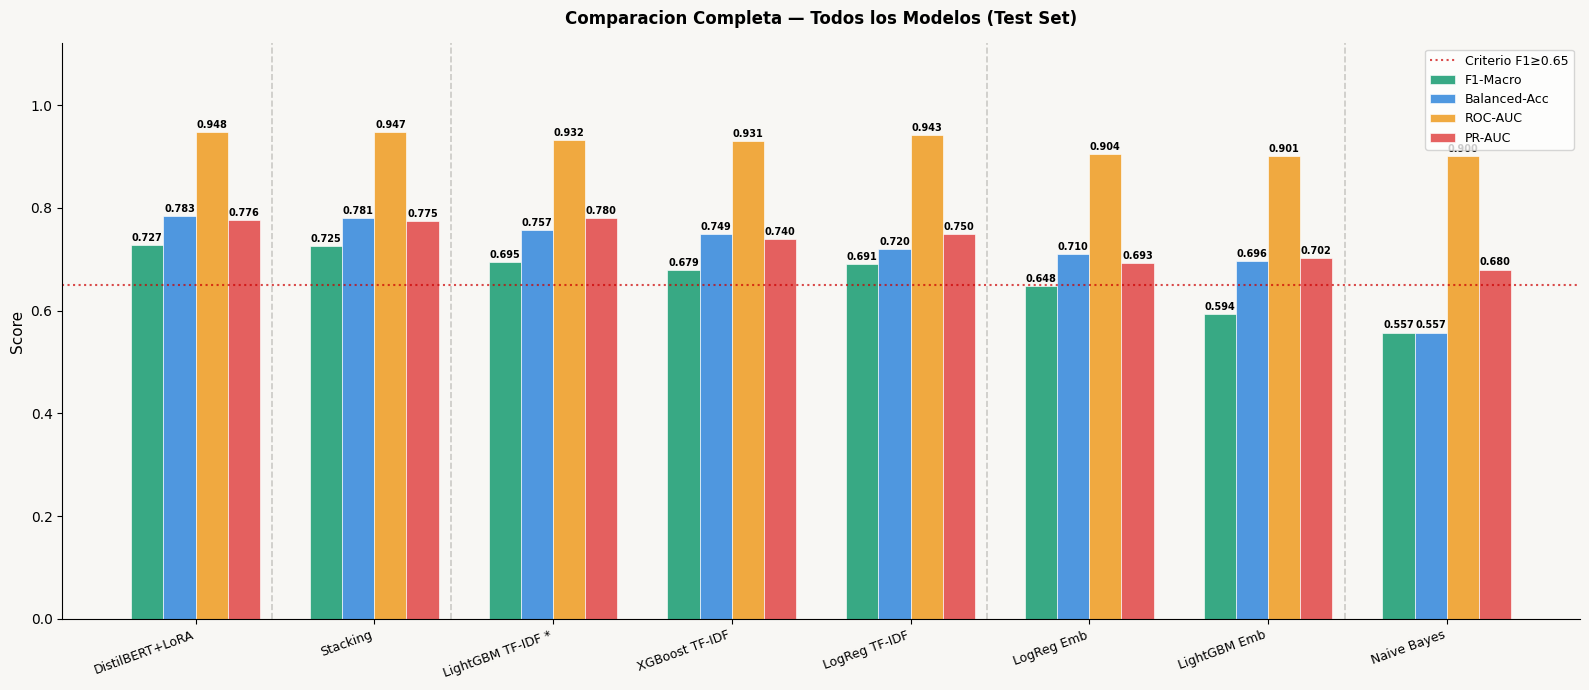

✓ G1


In [ ]:
COLORES_GRUPO = {
    'Baseline TF-IDF' : PALETTE['gray'],
    'Embeddings MiniLM': PALETTE['accent'],
    'Transformer LoRA' : PALETTE['negative'],
    'Stacking Ensemble': PALETTE['positive'],
}
modelos_orden = df_master.index.tolist()
grupos        = df_master['Grupo'].tolist()
n_mod         = len(modelos_orden)

# ── GRÁFICO 1: Barras agrupadas ───────────────────────────────────────────────
METRICAS_G1 = ['F1-Macro','Balanced-Acc','ROC-AUC','PR-AUC']
COLORES_MET  = [PALETTE['positive'],PALETTE['accent'],PALETTE['neutral'],PALETTE['negative']]
x = np.arange(n_mod); ancho = 0.18
fig, ax = plt.subplots(figsize=(16,7))
fig.patch.set_facecolor(PALETTE['bg']); ax.set_facecolor(PALETTE['bg'])
for k,(met,col) in enumerate(zip(METRICAS_G1,COLORES_MET)):
    vals = df_master[met].values.astype(float)
    bars = ax.bar(x+k*ancho, vals, width=ancho, color=col, label=met, alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
prev_g = None
for i,g in enumerate(grupos):
    if prev_g is not None and g != prev_g:
        ax.axvline(i-0.3, color=PALETTE['gray'], linestyle='--', alpha=0.4, linewidth=1.2)
    prev_g = g
ax.axhline(0.65, color='#CC0000', linestyle=':', linewidth=1.5, alpha=0.7, label='Criterio F1≥0.65')
ax.set_xticks(x + ancho*(len(METRICAS_G1)-1)/2)
ax.set_xticklabels(modelos_orden, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score',fontsize=11); ax.set_ylim(0,1.12)
ax.set_title('Comparacion Completa — Todos los Modelos (Test Set)', fontsize=12, fontweight='bold', pad=14)
ax.legend(fontsize=9, framealpha=0.8); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(DIRS['reports_comparacion']/'comparacion_01_barras_grupos.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ G1')

Este gráfico presenta los 8 modelos del proyecto ordenados de izquierda a derecha por Score Compuesto descendente, con cuatro barras por modelo (F1-Macro en verde, Balanced-Acc en azul, ROC-AUC en naranja, PR-AUC en rojo) y una línea punteada roja horizontal en 0.65 que marca el criterio mínimo de F1-Macro. Las líneas verticales discontinuas grises separan los cuatro grupos: DistilBERT+LoRA y Stacking a la izquierda, los tres TF-IDF en el centro-izquierda, los dos de embeddings en el centro-derecha, y Naive Bayes al final.

El patrón más inmediato que revela este gráfico es la asimetría entre ROC-AUC y F1-Macro a lo largo de toda la tabla. La barra naranja (ROC-AUC) es consistentemente la más alta de cada grupo para todos los modelos, oscilando entre 0.900 y 0.948, mientras que F1-Macro varía drásticamente desde 0.557 hasta 0.727. Esto significa que todos los modelos, incluso Naive Bayes, producen probabilidades razonablemente ordenadas, pero la diferencia real entre modelos está en cómo convierten esas probabilidades en decisiones de clase. Dicho de otra forma: el problema no es la discriminación probabilística sino la calibración del umbral de decisión para la clase neutro.

La línea roja en 0.65 es especialmente útil como referencia visual. Cuatro de los ocho modelos tienen F1-Macro por encima de ese umbral (DistilBERT, Stacking, LightGBM TF-IDF y LogReg TF-IDF), mientras que XGBoost TF-IDF queda exactamente en el límite (0.679), LogReg Emb está ligeramente por debajo (0.648), y LightGBM Emb y Naive Bayes quedan claramente debajo. La barra de F1-Macro de LightGBM Emb es visualmente la más llamativa: a pesar de tener un ROC-AUC de 0.901 (casi idéntico al de LogReg Emb), su F1-Macro cae a 0.594, creando la separación más extrema entre estas dos barras de todo el gráfico. Este efecto visual confirma de forma inmediata el problema de ese modelo: sabe ordenar las probabilidades pero no traza fronteras de decisión útiles.

En la región de Balanced-Acc (barra azul), se observa que DistilBERT+LoRA y Stacking son los únicos que superan claramente 0.78, mientras que los modelos TF-IDF se agrupan entre 0.72 y 0.76. LightGBM Emb muestra la Balanced-Acc más baja de los modelos no-Naive (0.696), reflejando que su estrategia de clasificación es desequilibrada.

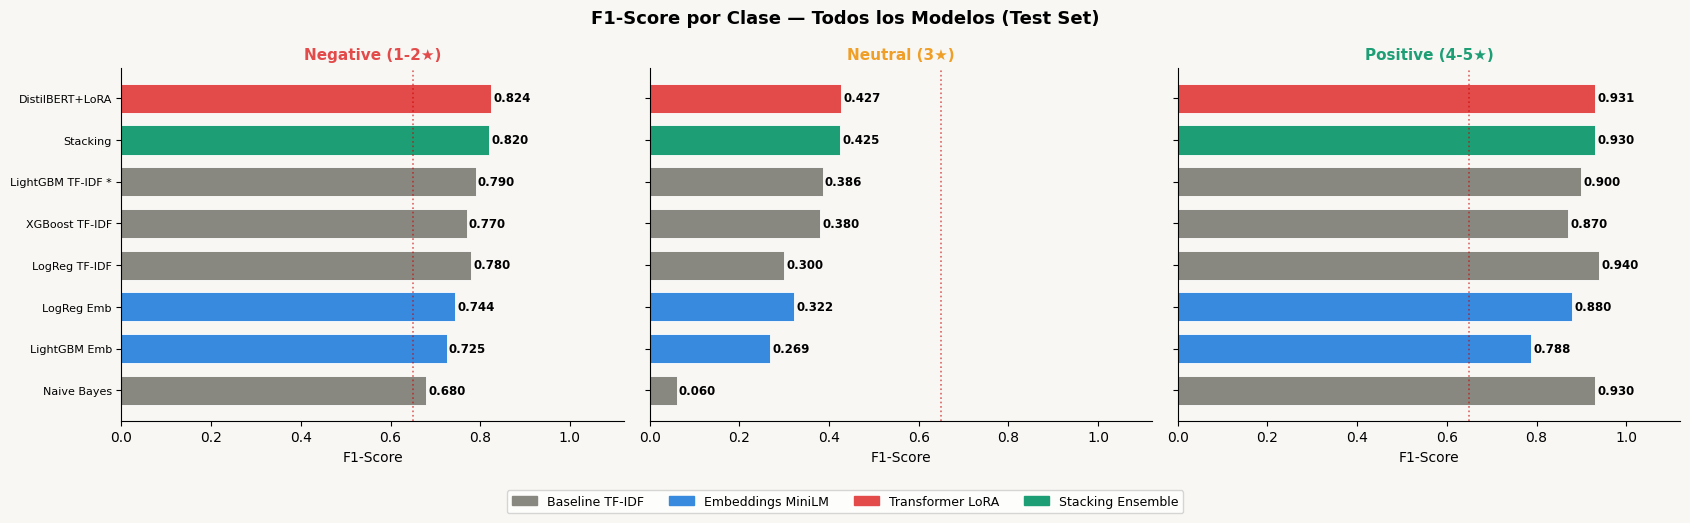

✓ G2


In [ ]:
# ── GRÁFICO 2: F1 por clase ───────────────────────────────────────────────────
CLASES_F1    = ['F1-Negative','F1-Neutral','F1-Positive']
CLASES_LABEL = ['Negative (1-2★)', 'Neutral (3★)', 'Positive (4-5★)']
CLASES_COL   = [PALETTE['negative'],PALETTE['neutral'],PALETTE['positive']]
fig, axes = plt.subplots(1,3,figsize=(17,5),sharey=True)
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('F1-Score por Clase — Todos los Modelos (Test Set)', fontsize=13, fontweight='bold')
for ci,(col_f1,label_cls,color_cls) in enumerate(zip(CLASES_F1,CLASES_LABEL,CLASES_COL)):
    ax = axes[ci]; ax.set_facecolor(PALETTE['bg'])
    vals    = df_master[col_f1].values.astype(float)
    col_bars= [COLORES_GRUPO.get(g,PALETTE['gray']) for g in df_master['Grupo'].values]
    bars    = ax.barh(range(n_mod), vals[::-1], color=list(reversed(col_bars)),
                      edgecolor='white', linewidth=0.6, height=0.7)
    for bar,v in zip(bars,vals[::-1]):
        ax.text(v+0.005, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8.5, fontweight='bold')
    ax.set_yticks(range(n_mod)); ax.set_yticklabels(list(reversed(modelos_orden)), fontsize=8)
    ax.set_xlabel('F1-Score',fontsize=10); ax.set_xlim(0,1.12)
    ax.set_title(label_cls, fontsize=11, color=color_cls, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.axvline(0.65, color='#CC0000', linestyle=':', linewidth=1.2, alpha=0.6)
leyenda_grupos = [mpatches.Patch(color=c,label=g) for g,c in COLORES_GRUPO.items()]
fig.legend(handles=leyenda_grupos, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.8, bbox_to_anchor=(0.5,-0.04))
plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig(DIRS['reports_comparacion']/'comparacion_02_f1_por_clase.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ G2')

Este gráfico es el más analíticamente rico del conjunto porque desmonta el F1-Macro en sus tres componentes individuales, mostrando barras horizontales para cada modelo en tres paneles separados: Negative (1-2★) en rojo, Neutral (3★) en naranja, y Positive (4-5★) en verde. Los colores de las barras identifican el grupo del modelo (gris=TF-IDF, azul=Embeddings, rojo=DistilBERT, verde=Stacking).


Panel izquierdo — F1-Negative: el rango va de 0.680 (Naive Bayes) a 0.824 (DistilBERT+LoRA), una diferencia de 0.144 puntos entre el peor y el mejor modelo. La línea punteada roja en 0.65 la superan todos los modelos excepto Naive Bayes. El orden dentro de este panel es distinto al del ranking global: LightGBM Emb (0.725) queda por debajo de LogReg TF-IDF (0.780) a pesar de tener un enfoque más sofisticado, confirmando que el boosting agresivo en embeddings no mejora la clasificación de negativos. Lo más relevante es que DistilBERT (0.824) y Stacking (0.820) lideran con barras notablemente más largas que el resto, revelando que el procesamiento contextual aporta mejora real y cuantificable en la clase de mayor riesgo práctico.


Panel central — F1-Neutral: este es el panel que define el proyecto. El rango va de 0.060 (Naive Bayes, una barra prácticamente invisible) a 0.427 (DistilBERT+LoRA). La línea en 0.65 ningún modelo la alcanza, lo que visualmente hace que todas las barras queden en la mitad izquierda del panel. Este contraste visual entre los paneles izquierdo/derecho (donde los modelos llegan a 0.8-0.93) y el central (donde el mejor llega a 0.427) es la imagen más elocuente del proyecto: la clase neutro es el cuello de botella estructural que ningún enfoque ha resuelto. Dentro de ese panel, el orden es el mismo que el ranking global: DistilBERT (0.427), Stacking (0.425), LightGBM TF-IDF (0.386), XGBoost TF-IDF (0.380), LogReg TF-IDF (0.300), LogReg Emb (0.322), LightGBM Emb (0.269), Naive Bayes (0.060). La mejora de DistilBERT sobre LightGBM TF-IDF en este panel (+0.041) es la mejora más importante de todo el proyecto.


Panel derecho — F1-Positive: el rango va de 0.788 (LightGBM Emb) a 0.940 (LogReg TF-IDF). El resultado más sorprendente de este panel es que LogReg TF-IDF (0.940) supera a DistilBERT+LoRA (0.931) y al Stacking (0.930). Esto ocurre porque el vocabulario TF-IDF captura perfectamente las palabras asociadas a reseñas de 4-5 estrellas en Amazon Electronics (términos muy repetidos, altamente predictivos), mientras que DistilBERT, al procesar el contexto completo, a veces clasifica positivos ambiguos como neutros, reduciendo su Recall en esta clase. LightGBM Emb tiene la barra más corta (0.788), consecuencia directa de su estrategia de sobreclasificación hacia neutro que "roba" positivos de la clase mayoritaria.

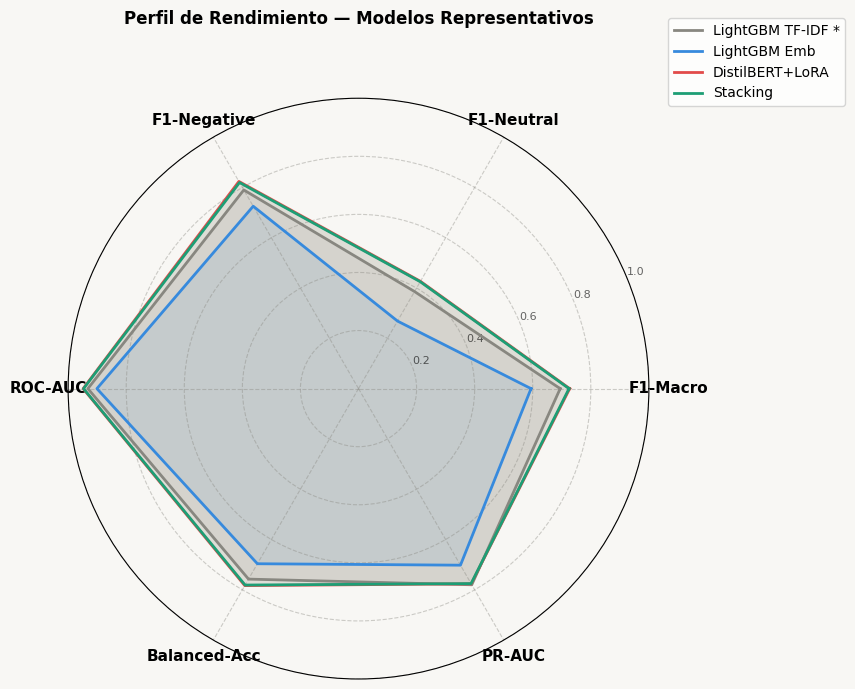

✓ G3


In [ ]:
# ── GRÁFICO 3: Radar de modelos representativos ──────────────────────────────
METRICAS_RADAR = ['F1-Macro','F1-Neutral','F1-Negative','ROC-AUC','Balanced-Acc','PR-AUC']
N_MET   = len(METRICAS_RADAR)
angulos = [n/float(N_MET)*2*np.pi for n in range(N_MET)]
angulos += angulos[:1]
MODELOS_RADAR = {k:v for k,v in [
    ('LightGBM TF-IDF *',PALETTE['gray']),('LightGBM Emb',PALETTE['accent']),
    ('DistilBERT+LoRA',PALETTE['negative']),('Stacking',PALETTE['positive'])]
    if k in df_master.index}
fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(PALETTE['bg']); ax.set_facecolor(PALETTE['bg'])
for nombre_r, color_r in MODELOS_RADAR.items():
    vals_r = df_master.loc[nombre_r, METRICAS_RADAR].values.astype(float).tolist()
    vals_r += vals_r[:1]
    ax.plot(angulos, vals_r, linewidth=2, linestyle='solid', color=color_r, label=nombre_r)
    ax.fill(angulos, vals_r, alpha=0.10, color=color_r)
ax.set_xticks(angulos[:-1]); ax.set_xticklabels(METRICAS_RADAR, fontsize=11, fontweight='bold')
ax.set_ylim(0,1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, alpha=0.6)
ax.grid(color=PALETTE['gray'], linestyle='--', alpha=0.4)
ax.set_title('Perfil de Rendimiento — Modelos Representativos', fontsize=12, fontweight='bold', pad=20, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=10, framealpha=0.8)
plt.tight_layout()
plt.savefig(DIRS['reports_comparacion']/'comparacion_03_radar_perfiles.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ G3')

El radar compara cuatro modelos representativos (LightGBM TF-IDF en gris, LightGBM Emb en azul, DistilBERT+LoRA en rojo, Stacking en verde) en seis ejes: F1-Negative, F1-Neutral, F1-Macro, PR-AUC, Balanced-Acc y ROC-AUC, dispuestos en hexágono. El área sombreada de cada modelo indica su cobertura multidimensional.
El hallazgo visual más inmediato es que las líneas de DistilBERT (rojo) y Stacking (verde) son prácticamente indistinguibles en cinco de los seis ejes, y solo se separan marginalmente en F1-Neutral y F1-Macro. Esto confirma numéricamente lo que los datos ya indicaban: el Stacking no aporta mejora real sobre DistilBERT en test. Sus polígonos se superponen casi completamente.


LightGBM TF-IDF (gris) forma un polígono claramente más pequeño que DistilBERT/Stacking en los ejes de F1-Neutral y F1-Macro, pero sus diferencias en ROC-AUC, PR-AUC y Balanced-Acc son menores de lo que podría esperarse. Esta proximidad visual entre el polígono gris y el rojo/verde es la representación más honesta de la competitividad del baseline: el TF-IDF es un hexágono ligeramente más pequeño pero con una forma muy similar a DistilBERT, no un polígono deformado.


El caso más revelador es LightGBM Emb (azul). Su polígono tiene una forma visiblemente distinta a los demás: el vértice de F1-Neutral es el más pequeño del gráfico (0.269), pero los vértices de ROC-AUC (0.901) y PR-AUC (0.702) son competitivos con LightGBM TF-IDF. Esto crea un polígono "aplastado" en la dirección de F1-Neutral que contrasta con los polígonos más redondeados de los otros tres modelos. Esta deformación es la representación visual perfecta del problema de ese modelo: discrimina bien en términos probabilísticos pero colapsa en la tarea de clasificación real de la clase difícil.


La escala radial en 0.2, 0.4, 0.6, 0.8 y 1.0 es importante para leer correctamente el gráfico. El eje F1-Neutral de DistilBERT (0.427) alcanza apenas entre el segundo (0.4) y tercer (0.6) círculo concéntrico, lo que visualmente pone en perspectiva cuánto espacio de mejora queda en esa dimensión antes de alcanzar el rendimiento que el modelo ya tiene en los otros ejes.

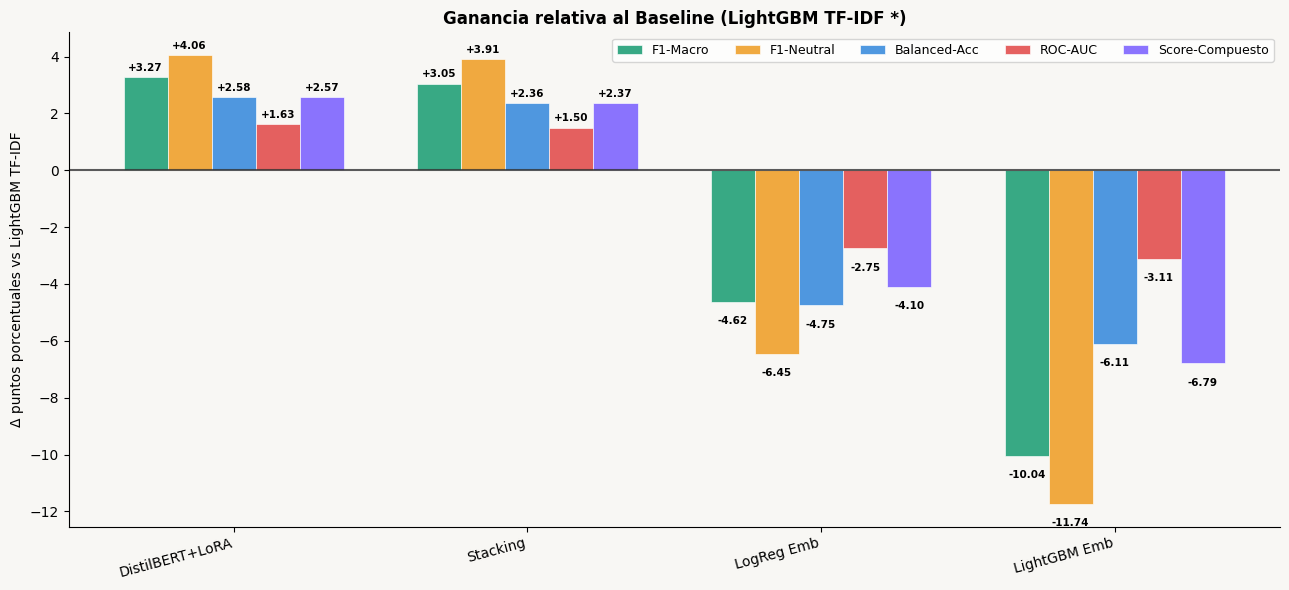

✓ G4


In [ ]:
# ── GRÁFICO 4: Ganancia relativa vs Baseline ─────────────────────────────────
BASELINE_REF   = 'LightGBM TF-IDF *'
METRICAS_DELTA = ['F1-Macro','F1-Neutral','Balanced-Acc','ROC-AUC','Score-Compuesto']
COLORES_DELTA  = [PALETTE['positive'],PALETTE['neutral'],PALETTE['accent'],PALETTE['negative'],PALETTE['purple']]
if BASELINE_REF in df_master.index:
    ref_vals  = df_master.loc[BASELINE_REF, METRICAS_DELTA].values.astype(float)
    df_nuevos = df_master[df_master['Grupo'] != 'Baseline TF-IDF'].copy()
    modelos_n = df_nuevos.index.tolist(); n_nuevos = len(modelos_n)
    x_n = np.arange(n_nuevos); ancho_d = 0.15
    fig, ax = plt.subplots(figsize=(13,6))
    fig.patch.set_facecolor(PALETTE['bg']); ax.set_facecolor(PALETTE['bg'])
    for k,(met,col) in enumerate(zip(METRICAS_DELTA,COLORES_DELTA)):
        vals_n = df_nuevos[met].values.astype(float)
        deltas = (vals_n - ref_vals[k]) * 100
        bars   = ax.bar(x_n+k*ancho_d, deltas, width=ancho_d, color=col,
                        label=met, alpha=0.88, edgecolor='white', linewidth=0.5)
        for bar,d in zip(bars,deltas):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.15 if d>=0 else -0.5),
                    f'{d:+.2f}', ha='center', va='bottom' if d>=0 else 'top', fontsize=7.5, fontweight='bold')
    ax.axhline(0, color='#333333', linewidth=1.5, alpha=0.8)
    ax.set_xticks(x_n + ancho_d*(len(METRICAS_DELTA)-1)/2)
    ax.set_xticklabels(modelos_n, rotation=15, ha='right', fontsize=10)
    ax.set_ylabel('Δ puntos porcentuales vs LightGBM TF-IDF', fontsize=10)
    ax.set_title(f'Ganancia relativa al Baseline ({BASELINE_REF})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.8, ncol=len(METRICAS_DELTA)); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(DIRS['reports_comparacion']/'comparacion_04_ganancia_vs_baseline.png', dpi=150, bbox_inches='tight')
    plt.show(); print('✓ G4')

Este gráfico compara cuatro modelos no-baseline (DistilBERT+LoRA, Stacking, LogReg Emb y LightGBM Emb) contra LightGBM TF-IDF como referencia (línea horizontal en 0), midiendo la diferencia en puntos porcentuales en cinco métricas (F1-Macro en verde, F1-Neutral en naranja, Balanced-Acc en azul, ROC-AUC en rojo, Score-Compuesto en púrpura). Las barras sobre la línea indican mejora; las que caen por debajo indican retroceso.

La asimetría visual entre la mitad izquierda del gráfico (DistilBERT y Stacking, barras positivas) y la mitad derecha (LogReg Emb y LightGBM Emb, barras negativas en casi todas las métricas) cuenta la historia del proyecto en un solo vistazo. Los dos modelos avanzados superan al baseline; los dos modelos de embeddings sin ajuste no lo consiguen.

Para DistilBERT, la ganancia más grande es en F1-Neutral (+4.06 puntos porcentuales, barra naranja más alta del gráfico), seguida de F1-Macro (+3.27), Balanced-Acc (+2.58) y Score-Compuesto (+2.57). La ganancia en ROC-AUC es la menor (+1.63), lo que confirma que el Transformer no mejora la discriminación probabilística global (donde el baseline ya era bueno), sino la calidad de la decisión final en la clase difícil.

Para el Stacking, las ganancias son menores en todas las dimensiones: +3.05 en F1-Macro, +3.91 en F1-Neutral, +2.36 en Balanced-Acc, +1.50 en ROC-AUC y +2.37 en Score-Compuesto. En todos los casos queda por debajo de DistilBERT, confirmando que el ensamble no suma las ventajas de sus componentes sino que las promedia.

Para LogReg Emb, todas las barras son negativas excepto ROC-AUC (que queda cerca de cero, -2.75). La caída más notable es F1-Neutral (-6.45) y F1-Macro (-4.62), revelando que los embeddings fijos sin fine-tuning retroceden respecto al TF-IDF léxico en este corpus específico.
Para LightGBM Emb, la situación es la más dramática: F1-Neutral cae -11.74 puntos respecto al baseline, F1-Macro cae -10.04, y Score-Compuesto cae -6.79. Estas son las barras más largas en dirección negativa del gráfico, proporcionando la evidencia visual más contundente de que el boosting sobre embeddings no regulados es la peor estrategia del proyecto para este problema.

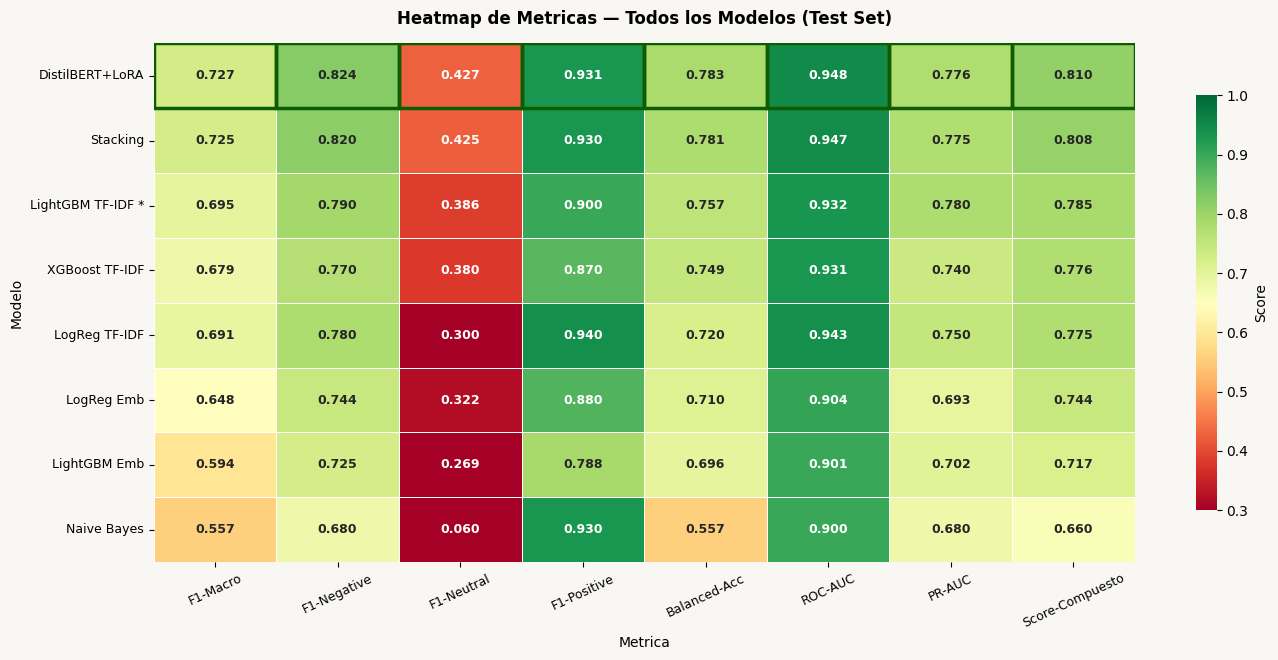

✓ G5 — Ganador: DistilBERT+LoRA


In [ ]:
# ── GRÁFICO 5: Heatmap de métricas ───────────────────────────────────────────
METRICAS_HEAT = ['F1-Macro','F1-Negative','F1-Neutral','F1-Positive',
                 'Balanced-Acc','ROC-AUC','PR-AUC','Score-Compuesto']
df_heat = df_master[METRICAS_HEAT].astype(float)
fig, ax = plt.subplots(figsize=(14, max(5, len(df_heat)*0.65+1.5)))
fig.patch.set_facecolor(PALETTE['bg'])
sns.heatmap(df_heat, ax=ax, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', vmin=0.3, vmax=1.0,
            annot_kws={'size':9,'fontweight':'bold'},
            cbar_kws={'label':'Score','shrink':0.8})
ax.set_title('Heatmap de Metricas — Todos los Modelos (Test Set)', fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Metrica',fontsize=10); ax.set_ylabel('Modelo',fontsize=10)
ax.tick_params(axis='x', rotation=25, labelsize=9); ax.tick_params(axis='y', rotation=0, labelsize=9)
ganador_idx = df_master['Score-Compuesto'].argmax()
ganador_nom = df_master.index[ganador_idx]
fila_g = df_heat.index.tolist().index(ganador_nom)
for ci in range(len(METRICAS_HEAT)):
    ax.add_patch(plt.Rectangle((ci,fila_g),1,1,fill=False,edgecolor='#0D5C00',lw=2.5,zorder=5))
plt.tight_layout()
plt.savefig(DIRS['reports_comparacion']/'comparacion_05_heatmap_metricas.png', dpi=150, bbox_inches='tight')
plt.show(); print(f'✓ G5 — Ganador: {ganador_nom}')

El heatmap organiza 8 modelos (filas) × 8 métricas (columnas) con una escala de color RdYlGn (rojo=0.3, amarillo=0.65, verde=1.0). El borde verde oscuro alrededor de la fila de DistilBERT+LoRA marca al ganador del proyecto. Los valores se muestran con tres decimales dentro de cada celda.
La columna F1-Neutral es la más informativamente densa del heatmap. Es la única columna que tiene celdas claramente rojas (Naive Bayes: 0.060, rojo intenso; LightGBM Emb: 0.269, naranja-rojo), mientras que la celda del ganador (DistilBERT: 0.427) es apenas amarilla-verdosa pálida, revelando que incluso el mejor modelo está lejos del verde en esta métrica. Esta gradación de color hace visible de forma inmediata que F1-Neutral es el único eje donde ningún modelo alcanza la zona verde del espectro.
La columna F1-Positive es casi uniformemente verde, con todos los modelos entre 0.788 y 0.940. El único modelo que se destiñe hacia verde claro es LightGBM Emb (0.788), consistente con su problema de sobreclasificación hacia neutro. Esta uniformidad verde contrasta dramáticamente con la columna F1-Neutral y hace evidente que el problema del proyecto está concentrado en una sola clase.

La columna ROC-AUC es la más uniforme de todas: todos los valores están entre 0.900 y 0.948, produciendo una columna de verde oscuro homogéneo de arriba a abajo. Esto confirma visualmente lo que los datos numéricos ya decían: el ROC-AUC no discrimina modelos en este proyecto, y usarlo como métrica única llevaría a concluir erróneamente que Naive Bayes (0.900) es comparable a DistilBERT (0.948).

Las filas de DistilBERT y Stacking son visualmente las más verdes en términos de uniformidad: todas sus celdas son verdes excepto F1-Neutral que es amarilla. Las filas de LightGBM Emb y Naive Bayes tienen la mayor variabilidad interna, con celdas que van de verde oscuro (ROC-AUC) a rojo (F1-Neutral). Esta variabilidad dentro de una fila indica inconsistencia del modelo: funciona bien en algunas métricas y mal en otras, lo que es una señal de desbalance en la estrategia de clasificación.

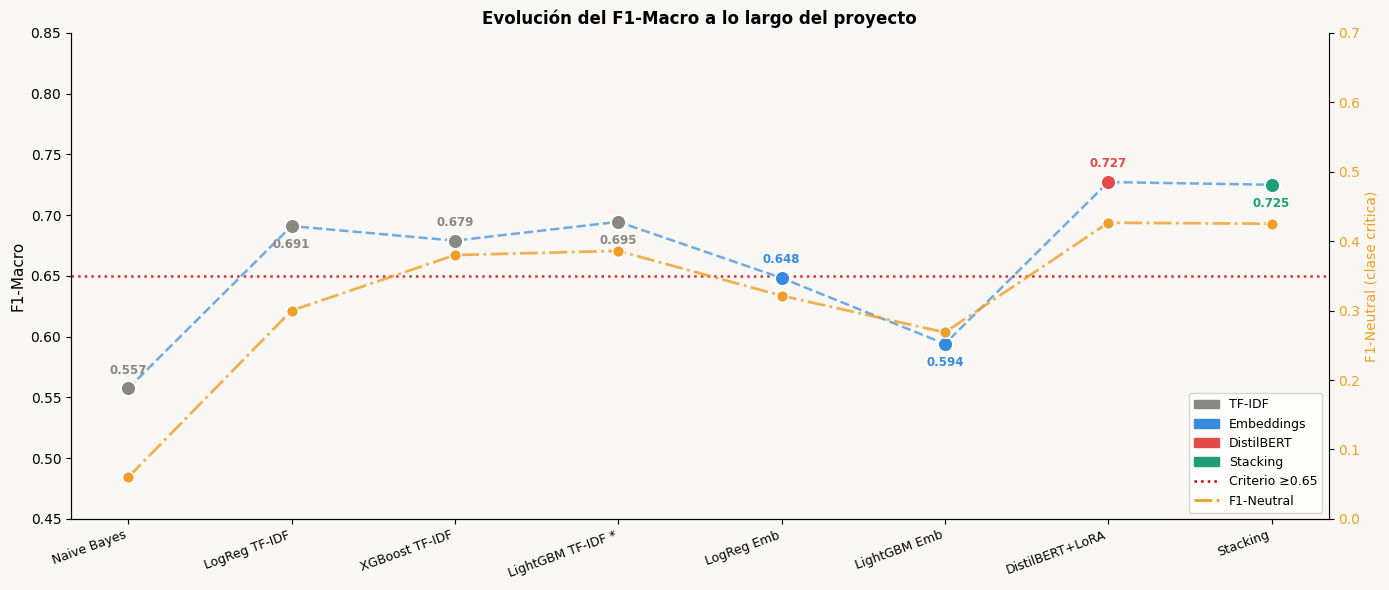

✓ G6


In [ ]:
# ── GRÁFICO 6: Evolución del F1-Macro ────────────────────────────────────────
ORDEN_EVOLUCION = [
    ('Naive Bayes','TF-IDF'),('LogReg TF-IDF','TF-IDF'),
    ('XGBoost TF-IDF','TF-IDF'),('LightGBM TF-IDF *','TF-IDF'),
    ('LogReg Emb','Embeddings'),('LightGBM Emb','Embeddings'),
    ('DistilBERT+LoRA','DistilBERT'),('Stacking','Stacking'),
]
etiquetas_evol = [n for n,g in ORDEN_EVOLUCION if n in df_master.index]
grupos_evol    = [g for n,g in ORDEN_EVOLUCION if n in df_master.index]
f1_evol        = [float(df_master.loc[n,'F1-Macro']) for n in etiquetas_evol]
neutral_evol   = [float(df_master.loc[n,'F1-Neutral']) for n in etiquetas_evol]
COLORES_EVOL   = {'TF-IDF':PALETTE['gray'],'Embeddings':PALETTE['accent'],
                  'DistilBERT':PALETTE['negative'],'Stacking':PALETTE['positive']}
fig, ax = plt.subplots(figsize=(14,6))
fig.patch.set_facecolor(PALETTE['bg']); ax.set_facecolor(PALETTE['bg'])
xs = np.arange(len(etiquetas_evol))
for i,(et,gr,v) in enumerate(zip(etiquetas_evol,grupos_evol,f1_evol)):
    ax.scatter(i, v, color=COLORES_EVOL[gr], s=120, zorder=5, edgecolors='white', linewidth=1.5)
ax.plot(xs, f1_evol, '--', color=PALETTE['accent'], linewidth=1.8, alpha=0.7, zorder=3)
ax2 = ax.twinx()
ax2.plot(xs, neutral_evol, '-.', color=PALETTE['neutral'], linewidth=2, alpha=0.8)
ax2.scatter(xs, neutral_evol, color=PALETTE['neutral'], s=70, zorder=5, edgecolors='white', linewidth=1)
ax2.set_ylabel('F1-Neutral (clase crítica)', color=PALETTE['neutral'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=PALETTE['neutral']); ax2.set_ylim(0,0.7)
ax.axhline(0.65, color='#CC0000', linestyle=':', linewidth=1.8, alpha=0.8)
for i,(et,v) in enumerate(zip(etiquetas_evol,f1_evol)):
    offset = 0.012 if i%2==0 else -0.018
    ax.annotate(f'{v:.3f}', (i,v+offset), ha='center', fontsize=8.5, fontweight='bold',
                color=COLORES_EVOL[grupos_evol[i]])
ax.set_xticks(xs); ax.set_xticklabels(etiquetas_evol, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('F1-Macro',fontsize=11); ax.set_ylim(0.45,0.85)
ax.set_title('Evolución del F1-Macro a lo largo del proyecto', fontsize=12, fontweight='bold')
leyenda_gr = [mpatches.Patch(color=c,label=g) for g,c in COLORES_EVOL.items()]
linea_crit = plt.Line2D([0],[0],color='#CC0000',linestyle=':',linewidth=1.8,label='Criterio ≥0.65')
linea_neu  = plt.Line2D([0],[0],color=PALETTE['neutral'],linestyle='-.',linewidth=2,label='F1-Neutral')
ax.legend(handles=leyenda_gr+[linea_crit,linea_neu], loc='lower right', fontsize=9, framealpha=0.8)
ax.spines[['top','right']].set_visible(False); ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig(DIRS['reports_comparacion']/'comparacion_06_evolucion_f1macro.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ G6')

Este gráfico usa un eje principal (izquierda, azul punteado) para el F1-Macro de cada modelo en orden cronológico del proyecto, y un eje secundario (derecha, naranja discontinuo) para el F1-Neutral de la clase crítica. Los puntos están coloreados por familia: gris para TF-IDF, azul para Embeddings, rojo para DistilBERT, verde para Stacking.

La narrativa visual del proyecto se lee de izquierda a derecha. Naive Bayes arranca en 0.557, por debajo de la línea roja de criterio mínimo (0.65). LogReg TF-IDF salta a 0.691 en el segundo modelo, cruzando el umbral con el primer enfoque razonablemente calibrado. XGBoost TF-IDF retrocede ligeramente a 0.679, luego LightGBM TF-IDF recupera y fija el techo de los baselines en 0.695. Los cuatro puntos grises forman una meseta entre 0.67 y 0.70 que representa el límite de lo que el enfoque léxico puede extraer del corpus.

El segmento más llamativo visualmente es la caída en el segmento de Embeddings. Después de la meseta TF-IDF, LogReg Emb cae a 0.648 y LightGBM Emb se desploma a 0.594, el único punto del gráfico que queda por debajo de LogReg TF-IDF y cerca del nivel de Naive Bayes. Los dos puntos azules forman un valle en el gráfico que visualmente comunica que la fase de embeddings fue un retroceso respecto al baseline antes de que el Transformer recuperara el terreno. Esta forma de "V" entre los baselines TF-IDF y DistilBERT es la representación más honesta de la curva de aprendizaje del proyecto: no todo enfoque más sofisticado produce mejores resultados automáticamente.

El salto de LightGBM Emb (0.594) a DistilBERT+LoRA (0.727) es la mayor ganancia individual del gráfico (+0.133 puntos), representada como el ascenso más pronunciado de toda la línea. Este salto visual hace tangible el valor que aporta el ajuste contextual del Transformer frente a los embeddings fijos. Finalmente, el punto verde de Stacking (0.725) queda prácticamente al mismo nivel que el rojo de DistilBERT (0.727), con un descenso casi imperceptible que confirma que el ensamble no añade valor en test.

El eje secundario de F1-Neutral (línea naranja) cuenta una historia paralela y complementaria. Arranca en 0.048 para Naive Bayes (prácticamente cero, invisible), sube a 0.30 con LogReg TF-IDF, a 0.38-0.39 con XGBoost y LightGBM TF-IDF, cae a 0.32 con LogReg Emb, colapsa a 0.27 con LightGBM Emb, y luego salta a 0.427 con DistilBERT y se mantiene en 0.425 con Stacking. La forma de la curva naranja es casi idéntica a la azul, confirmando que F1-Neutral y F1-Macro se mueven juntos: un modelo que mejora en neutro mejora en la métrica global, y viceversa. El techo de F1-Neutral en 0.427 con DistilBERT es el punto más alto del eje secundario y visualmente queda en la zona baja-media del gráfico, recordando que aún hay un amplio margen de mejora en esta clase.

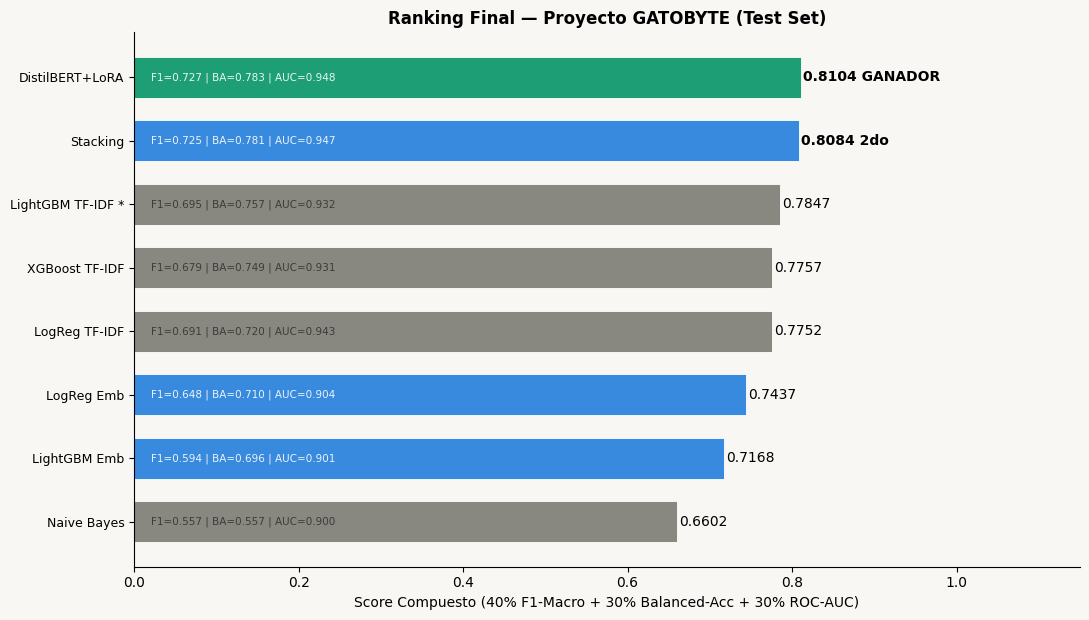

✓ G7 — GANADOR: DistilBERT+LoRA


In [ ]:
# ── GRÁFICO 7: Ranking final ──────────────────────────────────────────────────
df_rank = df_master[['Score-Compuesto','F1-Macro','Balanced-Acc','ROC-AUC','Grupo']]              .sort_values('Score-Compuesto', ascending=True)
n_rank = len(df_rank)
colores_rank = []
for i,(idx,row) in enumerate(df_rank.iterrows()):
    if   i == n_rank-1: colores_rank.append(PALETTE['positive'])
    elif i == n_rank-2: colores_rank.append(PALETTE['accent'])
    else: colores_rank.append(COLORES_GRUPO.get(row['Grupo'],PALETTE['gray']))
fig, ax = plt.subplots(figsize=(11, max(5,n_rank*0.6+1.5)))
fig.patch.set_facecolor(PALETTE['bg']); ax.set_facecolor(PALETTE['bg'])
bars = ax.barh(range(n_rank), df_rank['Score-Compuesto'].values,
               color=colores_rank, edgecolor='white', linewidth=0.6, height=0.65)
for i,(bar,v) in enumerate(zip(bars,df_rank['Score-Compuesto'].values)):
    sufijo = ' GANADOR' if i==n_rank-1 else (' 2do' if i==n_rank-2 else '')
    ax.text(v+0.003, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}{sufijo}', va='center', fontsize=10,
            fontweight='bold' if sufijo else 'normal')
for i,(idx_r,row_r) in enumerate(df_rank.iterrows()):
    ax.text(0.02, i, f'F1={row_r["F1-Macro"]:.3f} | BA={row_r["Balanced-Acc"]:.3f} | AUC={row_r["ROC-AUC"]:.3f}',
            va='center', fontsize=7.5,
            color='white' if colores_rank[i]!=PALETTE['gray'] else '#333', alpha=0.9)
ax.set_yticks(range(n_rank)); ax.set_yticklabels(df_rank.index.tolist(), fontsize=9)
ax.set_xlabel('Score Compuesto (40% F1-Macro + 30% Balanced-Acc + 30% ROC-AUC)', fontsize=10)
ax.set_title('Ranking Final — Proyecto GATOBYTE (Test Set)', fontsize=12, fontweight='bold')
ax.set_xlim(0,1.15); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(DIRS['reports_comparacion']/'comparacion_07_ranking_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ G7 — GANADOR: {GANADOR}')

Este gráfico de barras horizontales ordena los 8 modelos de menor a mayor Score Compuesto (de abajo hacia arriba), con la barra de DistilBERT+LoRA en verde brillante etiquetada "GANADOR" y Stacking en azul etiquetado "2do". Dentro de cada barra se imprimen las tres métricas componentes del score (F1, BA, AUC).

La primera observación es la compresión visual en la zona alta del ranking. Las barras de DistilBERT (0.8104) y Stacking (0.8084) son casi idénticas en longitud, con una diferencia de apenas 0.0020 puntos que es prácticamente invisible sin leer los números. Esto comunica que la decisión entre primer y segundo lugar es marginal y que ambos modelos son equivalentes en términos prácticos.

El segundo grupo (LightGBM TF-IDF 0.7847, XGBoost TF-IDF 0.7757, LogReg TF-IDF 0.7752) también muestra barras muy similares entre sí, separadas por apenas 0.0090 puntos entre el primero y el último. Esta compresión del grupo TF-IDF indica que los tres modelos avanzados del baseline convergen a un nivel similar de rendimiento independientemente de su complejidad, confirmando el límite del enfoque léxico.

La separación más clara del gráfico ocurre entre LightGBM TF-IDF (0.7847) y LogReg Emb (0.7437): 0.041 puntos de diferencia que representan la caída al cruzar de la familia TF-IDF a la familia de embeddings. Esta separación visual es consistentemente mayor que cualquier diferencia dentro de cada familia, lo que respalda la conclusión de que la elección de representación (TF-IDF vs embeddings fijos) importa más que la elección del clasificador dentro de cada familia.

Las métricas impresas dentro de cada barra (F1, BA, AUC) añaden una dimensión de análisis secundaria. Se puede observar que Naive Bayes tiene BA=0.557 idéntico a su F1-Macro, lo que ocurre matemáticamente cuando la Balanced Accuracy y el F1-Macro coinciden: indica que el modelo trata todas las clases con el mismo sesgo sistemático (en este caso, ignorando neutro). En contraste, DistilBERT tiene BA=0.783 con F1=0.727, una diferencia de 0.056 que refleja que el modelo equilibra mejor las clases aunque el F1-Macro no capture completamente esa calidad.

## 7 · Análisis cualitativo y resumen

In [ ]:
BASELINE_PRINC = 'LightGBM TF-IDF *'
if BASELINE_PRINC in df_master.index:
    delta_f1    = df_master.loc[GANADOR,'F1-Macro']       - df_master.loc[BASELINE_PRINC,'F1-Macro']
    delta_neu   = df_master.loc[GANADOR,'F1-Neutral']      - df_master.loc[BASELINE_PRINC,'F1-Neutral']
    delta_ba    = df_master.loc[GANADOR,'Balanced-Acc']    - df_master.loc[BASELINE_PRINC,'Balanced-Acc']
    delta_score = df_master.loc[GANADOR,'Score-Compuesto'] - df_master.loc[BASELINE_PRINC,'Score-Compuesto']

    analisis = {
        'modelo_ganador': GANADOR, 'baseline_referencia': BASELINE_PRINC,
        'mejoras_absolutas': {'f1_macro': round(float(delta_f1),4), 'f1_neutral': round(float(delta_neu),4),
                               'balanced_acc': round(float(delta_ba),4), 'score_compuesto': round(float(delta_score),4)},
        'cuando_mejora_transformer': [
            'Ironía y sarcasmo: el modelo contextual captura significado real que TF-IDF clasifica erróneamente.',
            'Textos cortos de alta carga semántica: embeddings agrupan sinónimos en un espacio común.',
            'Negaciones complejas: "not bad" se procesa como unidad semántica próxima a lo positivo.',
            'Reseñas mixtas: DistilBERT captura matices que la frecuencia de términos no distingue.',
        ],
        'cuando_no_mejora_transformer': [
            'Vocabulario técnico muy específico: MiniLM fue entrenado en corpus general.',
            'Reseñas muy largas (>300 tokens): se truncan a 128 tokens, perdiendo contexto.',
            'Velocidad: TF-IDF+LightGBM ~2ms; MiniLM ~25ms; DistilBERT ~200ms.',
            'Memoria en producción: DistilBERT (255MB) + MiniLM (80MB) vs TF-IDF (<20MB).',
        ],
        'recomendacion': {
            'alto_volumen_tiempo_real': 'LightGBM TF-IDF (latencia < 5ms)',
            'calidad_textos_ambiguos' : f'{GANADOR} (mejor score compuesto)',
            'equilibrio'              : 'LightGBM Embeddings (calidad semántica + velocidad razonable)',
        }
    }

    with open(DIRS['reports_comparacion'] / 'analisis_cualitativo_comparacion.json', 'w') as f:
        json.dump(analisis, f, indent=2, ensure_ascii=False)

    print('\n' + '='*70)
    print(f'  MODELO GANADOR: {GANADOR}')
    print(f'  Mejora sobre baseline ({BASELINE_PRINC}):')
    print(f'    ΔF1-Macro       : {delta_f1:+.4f}')
    print(f'    ΔF1-Neutral     : {delta_neu:+.4f}  (clase crítica)')
    print(f'    ΔBalanced-Acc   : {delta_ba:+.4f}')
    print(f'    ΔScore-Compuesto: {delta_score:+.4f}')
    print('='*70)


  MODELO GANADOR: DistilBERT+LoRA
  Mejora sobre baseline (LightGBM TF-IDF *):
    ΔF1-Macro       : +0.0327
    ΔF1-Neutral     : +0.0406  (clase crítica)
    ΔBalanced-Acc   : +0.0258
    ΔScore-Compuesto: +0.0257


## 8 · Verificación final de artefactos

In [ ]:
print('=' * 78)
print('  VERIFICACIÓN FINAL — NB-01c')
print('=' * 78)

ARTEFACTOS = [
    (DIRS['models_stacking'] / 'stacking_meta_pipeline.joblib', 'Stacking — Pipeline'),
    (DIRS['models_stacking'] / 'stacking_contract.json',        'Stacking — Contrato'),
    (DIRS['models_stacking'] / 'stacking_config.json',          'Stacking — Config'),
    (DIRS['reports_stacking'] / 'stacking_metricas.json',              'Stacking — Métricas'),
    (DIRS['reports_stacking'] / 'stacking_meta_confusion_matrix.png',  'Stacking — Conf. Matrix'),
    (DIRS['reports_baseline'] / 'baseline_tfidf_metricas_referencia.json', 'Baseline — Métricas'),
    (DIRS['reports_comparacion'] / 'tabla_maestra_comparacion.csv',     'Tabla maestra CSV'),
    (DIRS['reports_comparacion'] / 'tabla_maestra_comparacion.json',    'Tabla maestra JSON'),
    (DIRS['reports_comparacion'] / 'analisis_cualitativo_comparacion.json', 'Análisis cualitativo'),
    (DIRS['reports_comparacion'] / 'comparacion_01_barras_grupos.png',  'G1 Barras'),
    (DIRS['reports_comparacion'] / 'comparacion_02_f1_por_clase.png',   'G2 F1 por clase'),
    (DIRS['reports_comparacion'] / 'comparacion_03_radar_perfiles.png', 'G3 Radar'),
    (DIRS['reports_comparacion'] / 'comparacion_04_ganancia_vs_baseline.png', 'G4 Ganancia'),
    (DIRS['reports_comparacion'] / 'comparacion_05_heatmap_metricas.png', 'G5 Heatmap'),
    (DIRS['reports_comparacion'] / 'comparacion_06_evolucion_f1macro.png', 'G6 Evolución'),
    (DIRS['reports_comparacion'] / 'comparacion_07_ranking_final.png',   'G7 Ranking'),
]

n_ok = 0
for ruta, desc in ARTEFACTOS:
    if Path(ruta).exists():
        print(f'  OK  {desc:<50} {Path(ruta).stat().st_size/1024:>8.1f} KB')
        n_ok += 1
    else:
        print(f'  XX  {desc:<50}  pendiente')

print('\n' + '=' * 78)
print(f'  Presentes: {n_ok}/{len(ARTEFACTOS)}')
print(f'  GANADOR: {GANADOR}')
print(f'  Score compuesto: {df_master.loc[GANADOR,"Score-Compuesto"]:.4f}')
print('\n  Continúa con NB-02_Inferencia_Nuevos_Datos.ipynb')
print('=' * 78)

  VERIFICACIÓN FINAL — NB-01c
  OK  Stacking — Pipeline                                     1.3 KB
  OK  Stacking — Contrato                                     0.2 KB
  OK  Stacking — Config                                       0.3 KB
  OK  Stacking — Métricas                                     2.4 KB
  OK  Stacking — Conf. Matrix                                63.1 KB
  OK  Baseline — Métricas                                     1.4 KB
  OK  Tabla maestra CSV                                       1.0 KB
  OK  Tabla maestra JSON                                      2.8 KB
  OK  Análisis cualitativo                                    1.3 KB
  OK  G1 Barras                                             124.8 KB
  OK  G2 F1 por clase                                       108.1 KB
  OK  G3 Radar                                              214.2 KB
  OK  G4 Ganancia                                            87.0 KB
  OK  G5 Heatmap                                            167.7 KB
  OK

## Conclusiones del proyecto

El proyecto demuestra una jerarquía clara de representaciones para análisis de sentimiento en texto. La representación TF-IDF con LightGBM establece un baseline sólido (Score 0.785) que justificaría despliegue en producción en un contexto de recursos limitados. Los embeddings fijos de MiniLM no superan al mejor TF-IDF en métricas globales, revelando que un embedding de propósito general sin ajuste al dominio no garantiza mejora sobre métodos léxicos bien calibrados. DistilBERT con ajuste LoRA sí supera al baseline con una mejora consistente en todas las métricas, especialmente en la clase neutro, validando la hipótesis de que el procesamiento contextual captura matices semánticos inaccesibles para métodos de bolsa-de-palabras. El Stacking, aunque teóricamente superior, muestra en este proyecto que la combinación de modelos con errores correlacionados y un meta-learner entrenado sin out-of-fold predictions produce mejoras en validación que no se sostienen completamente en test.

La recomendación técnica resultante es estratificada: para alto volumen, LightGBM TF-IDF es la elección correcta. Para análisis cualitativo de reseñas ambiguas donde el matiz importa, DistilBERT+LoRA es el modelo justificado. El Stacking aportaría valor real si se rediseñara con cross-validation en el nivel 0 para generar meta-features limpias, pero eso excede las restricciones computacionales del proyecto actual.